# **Assignment 0 — Task 1: Inner Workings of ResNet-152**
- `Name  : Rana Taqveem Ul Hassan`
- `Roll #: 25280030`

Reused/adapted from prior coursework: reproducibility + device setup, generic
train/eval loop utilities, ImageNet-normalization transform pipeline, the
pretrained-backbone freeze + head-replacement pattern, and the per-block
feature-extraction pattern. Everything else below is scaffolding for the new
Task 1 sub-tasks (skip-connection ablation, t-SNE/UMAP, transfer-learning
comparisons) that had no equivalent code in the old notebook.

In [1]:
import os
import gc
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.manifold import TSNE
# import umap  # pip install umap-learn -- optional, for Task 1.5 (t-SNE vs UMAP)
import seaborn as sns
import random

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

Using Device: cuda


In [2]:
# ---- Colab efficiency setup ----
# Mount Drive once so the dataset + pretrained weights + checkpoints/features
# persist across session restarts (avoids re-downloading ResNet-152 weights
# and re-running the CIFAR-10 download every time Colab disconnects).
try:
    from google.colab import drive
    drive.mount('/content/drive')
    RUN_DIR = '/content/drive/MyDrive/ATML/assignment_00/task1_resnet152'
except ImportError:
    RUN_DIR = './task1_resnet152'  # not on Colab

os.makedirs(RUN_DIR, exist_ok=True)
os.makedirs(f'{RUN_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{RUN_DIR}/features', exist_ok=True)
DATA_ROOT = f'{RUN_DIR}/data'          # torchvision dataset cache (survives restarts)
TORCH_HOME = f'{RUN_DIR}/torch_cache'  # pretrained-weights cache (survives restarts)
os.environ['TORCH_HOME'] = TORCH_HOME

# DRY_RUN: validate every code path on a tiny slice + 1 epoch before spending
# real GPU time. Always run once with this True, THEN flip to False.
DRY_RUN = False
SUBSET_TRAIN = 512 if DRY_RUN else 8000   # cap on training images used
SUBSET_EVAL = 256 if DRY_RUN else 2000    # cap on val/test images used
NUM_EPOCHS = 1 if DRY_RUN else 5

print(f"RUN_DIR={RUN_DIR}")
print(f"DRY_RUN={DRY_RUN} | train={SUBSET_TRAIN} eval={SUBSET_EVAL} epochs={NUM_EPOCHS}")

def save_checkpoint(state_dict, name):
    path = f'{RUN_DIR}/checkpoints/{name}.pt'
    torch.save(state_dict, path)
    print(f"saved -> {path}")

def load_checkpoint(name, map_location=None):
    path = f'{RUN_DIR}/checkpoints/{name}.pt'
    return torch.load(path, map_location=map_location or DEVICE) if os.path.exists(path) else None

Mounted at /content/drive
RUN_DIR=/content/drive/MyDrive/ATML/assignment_00/task1_resnet152
DRY_RUN=False | train=8000 eval=2000 epochs=5


## 1. Baseline Setup
(a) Use a pre-trained ResNet-152 from PyTorch.
(b) Replace the final classification layer to match a smaller dataset such as CIFAR-10.
(c) Train only the classification head while freezing the rest of the backbone.
(d) Record training and validation performance for a few epochs.

In [3]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

resnet_transformer_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

resnet_transformer_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [4]:
BATCH_SIZE = 64
NUM_CLASSES = 10

train_cifar_ds = datasets.CIFAR10(root=DATA_ROOT, transform=resnet_transformer_train, download=True, train=True)
test_cifar_ds = datasets.CIFAR10(root=DATA_ROOT, transform=resnet_transformer_test, download=True, train=False)

classes_cifar = train_cifar_ds.classes
print(classes_cifar)

# Subset sizes are driven by DRY_RUN / SUBSET_TRAIN / SUBSET_EVAL from the
# Colab efficiency setup cell above -- bump SUBSET_TRAIN/EVAL once DRY_RUN is
# False and you're ready to spend real GPU time on the full run.
g = torch.Generator().manual_seed(42)
train_idx = torch.randperm(len(train_cifar_ds), generator=g)
val_take = min(SUBSET_EVAL, len(train_cifar_ds) - SUBSET_TRAIN)
train_subset = torch.utils.data.Subset(train_cifar_ds, train_idx[:SUBSET_TRAIN].tolist())
val_subset = torch.utils.data.Subset(train_cifar_ds, train_idx[SUBSET_TRAIN:SUBSET_TRAIN + val_take].tolist())

test_idx = torch.randperm(len(test_cifar_ds), generator=g)[:SUBSET_EVAL].tolist()
test_subset = torch.utils.data.Subset(test_cifar_ds, test_idx)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train Samples: {len(train_subset)} | Val Samples: {len(val_subset)} | Test Samples: {len(test_subset)}")

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train Samples: 8000 | Val Samples: 2000 | Test Samples: 2000


In [5]:
TRAIN_LOSS = 'train_loss'
TRAIN_ACC = 'train_acc'
VAL_LOSS = 'val_loss'
VAL_ACC = 'val_acc'

def count_parameters(model):
  return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_one_epoch(model, loader, criterion, optimizer, scaler=None):
    model.train()

    total_loss = 0.0
    accurate_predictions = 0
    sample_count = 0
    for images, labels in loader:
      optimizer.zero_grad()
      # .float() upcasts in case this loader yields fp16-cached features
      # (see extract_features/extract_stage_features) -- raw image batches
      # are already fp32, so this is a no-op for those.
      images = images.to(DEVICE).float()
      labels = labels.to(DEVICE)

      if scaler is not None:
        # AMP path -- only the full-backbone fine-tuning run needs this,
        # since that's the only case where every layer needs a fresh
        # gradient every epoch and the extra cost is unavoidable.
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16):
          outputs = model(images)
          loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
      else:
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

      _, predicted_classes = torch.max(outputs.data, 1)
      accurate_predictions += (predicted_classes == labels).sum().item()

      total_loss += loss.item() * images.size(0)
      sample_count += images.size(0)

    avg_loss = total_loss / sample_count
    accuracy = 100 * accurate_predictions / sample_count

    return avg_loss, accuracy

def evaluate(model, loader, criterion):

    model.eval()

    total_loss = 0.0
    accurate_predictions = 0
    sample_count = 0

    with torch.no_grad():
      for images, labels in loader:
        images = images.to(DEVICE).float()  # upcast in case of fp16-cached features
        outputs = model(images)

        labels = labels.to(DEVICE)
        loss = criterion(outputs, labels)
        _, predicted_classes = torch.max(outputs.data, 1)
        accurate_predictions += (predicted_classes == labels).sum().item()

        total_loss += loss.item() * images.size(0)
        sample_count += images.size(0)

    avg_loss = total_loss / sample_count
    accuracy = 100 * accurate_predictions / sample_count

    return avg_loss, accuracy

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=7, scaler=None):
  results = {
      TRAIN_LOSS: [],
      TRAIN_ACC: [],
      VAL_LOSS: [],
      VAL_ACC : []
  }

  for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler=scaler)
    results[TRAIN_LOSS].append(train_loss)
    results[TRAIN_ACC].append(train_acc)

    val_loss, val_acc = evaluate(model, val_loader, criterion=criterion)
    results[VAL_LOSS].append(val_loss)
    results[VAL_ACC].append(val_acc)

    print(f"Epoch: {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss {val_loss:.2f}% Val Acc:{val_acc:.2f}%")

  return results

def test_and_report(model, test_loader, criterion, classes):

  test_loss, test_acc = evaluate(model, test_loader, criterion)

  y_true = []
  y_pred = []

  model.eval()
  with torch.no_grad():
    for images, labels in test_loader:
      images = images.to(DEVICE)
      labels = labels.to(DEVICE)

      outputs = model(images)
      _, predictions = torch.max(outputs.data, 1)

      y_true.extend(labels.cpu().tolist())
      y_pred.extend(predictions.cpu().tolist())

  print("-" * 30)
  print(f"FINAL TEST RESULT")
  print(f"Test Loss: {test_loss:.4f}")
  print(f"Test Accuracy: {test_acc:.2f}%")
  print("-" * 30)

  classes_list = [str(c) for c in classes]

  cr = classification_report(y_true, y_pred, target_names=classes_list, zero_division=0)
  print("\nClassification Report:\n", cr)

  return test_loss, test_acc, y_true, y_pred

def plot_loss_acc(results):
  plt.figure(figsize=(6,4))
  plt.plot(results[TRAIN_LOSS], label='Training Loss')
  plt.plot(results[VAL_LOSS], label='Validation Loss')
  plt.legend()

  plt.figure(figsize=(6,4))
  plt.plot(results[TRAIN_ACC], label='Training Accuracy')
  plt.plot(results[VAL_ACC], label='Validation Accuracy')
  plt.legend()

def extract_features(model, loader, cache_path=None):
    """Run a frozen backbone forward pass once and cache pooled features +
    labels. Reusable for any frozen-backbone experiment (baseline, residual
    ablation, the frozen-backbone arm of the transfer-learning comparison) --
    avoids re-running the expensive ResNet forward pass every training epoch.
    """
    if cache_path and os.path.exists(cache_path):
        data = torch.load(cache_path)
        return data['X'], data['y']

    model.eval()
    feats, labels = [], []
    with torch.no_grad():
        for images, y in tqdm(loader, desc="extracting features"):
            images = images.to(DEVICE)
            x = model.conv1(images)
            x = model.maxpool(model.relu(model.bn1(x)))
            x = model.layer1(x)
            x = model.layer2(x)
            x = model.layer3(x)
            x = model.layer4(x)
            x = model.avgpool(x).flatten(1)   # (batch, 2048)
            feats.append(x.cpu().half())  # fp16 -- halves RAM for the cached tensor
            labels.append(y)
    X = torch.cat(feats)
    y_all = torch.cat(labels)
    if cache_path:
        torch.save({'X': X, 'y': y_all}, cache_path)
    return X, y_all

def train_head_on_features(X_train, y_train, X_val, y_val, num_classes, num_epochs=NUM_EPOCHS, lr=1e-3, batch_size=256, normalize_features=False):
    """Train just the linear classification head on cached features. This is
    where you should now do most of your epoch/hyperparameter iteration --
    it's pure matmul on cached tensors, so extra epochs here are ~free.

    normalize_features: prepends a BatchNorm1d before the linear layer to
    recalibrate feature scale. Off by default -- preserves the already-
    recorded pretrained-backbone results exactly. Needed for a random-init
    backbone, whose never-calibrated BatchNorm running stats can make raw
    feature magnitudes huge enough to destabilize training (this is exactly
    what caused the frozen+random-init run's loss to blow up to the millions).
    """
    in_features = X_train.shape[1]
    if normalize_features:
        head = nn.Sequential(nn.BatchNorm1d(in_features), nn.Linear(in_features, num_classes)).to(DEVICE)
    else:
        head = nn.Linear(in_features, num_classes).to(DEVICE)
    optimizer = optim.Adam(head.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_loader_f = DataLoader(torch.utils.data.TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader_f = DataLoader(torch.utils.data.TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

    results = train_model(head, train_loader_f, val_loader_f, criterion, optimizer, num_epochs=num_epochs)
    return head, results

class FinalBlockHead(nn.Module):
    """Wraps a (possibly pretrained) layer4 + avgpool + a fresh fc so it can
    be trained on cached layer3 features exactly like any other model --
    train_model/evaluate call it as model(x), same as everywhere else."""
    def __init__(self, layer4, avgpool, fc):
        super().__init__()
        self.layer4 = layer4
        self.avgpool = avgpool
        self.fc = fc

    def forward(self, x):
        x = self.layer4(x)
        x = self.avgpool(x).flatten(1)
        return self.fc(x)

class FinalBlockHead(nn.Module):
    """Wraps a (possibly pretrained) layer4 + avgpool + a fresh fc so it can
    be trained on cached layer3 features exactly like any other model --
    train_model/evaluate call it as model(x), same as everywhere else."""
    def __init__(self, layer4, avgpool, fc):
        super().__init__()
        self.layer4 = layer4
        self.avgpool = avgpool
        self.fc = fc

    def forward(self, x):
        x = self.layer4(x)
        x = self.avgpool(x).flatten(1)
        return self.fc(x)

def extract_stage_features(model, loader, cache_path=None):
    """Same idea as extract_features, but stops after layer3 instead of
    avgpool. For the 'final block' fine-tuning runs, everything through
    layer3 stays frozen, so its output can be cached once and reused every
    epoch -- only layer4 (+ head) needs a fresh forward/backward pass."""
    if cache_path and os.path.exists(cache_path):
        data = torch.load(cache_path)
        return data['X'], data['y']

    model.eval()
    feats, labels = [], []
    with torch.no_grad():
        for images, y in tqdm(loader, desc="extracting layer3 features"):
            images = images.to(DEVICE)
            x = model.conv1(images)
            x = model.maxpool(model.relu(model.bn1(x)))
            x = model.layer1(x)
            x = model.layer2(x)
            x = model.layer3(x)
            # fp16 -- layer3's spatial maps (14x14x1024/image) are ~200x
            # bigger per-image than the final pooled vector, so halving
            # precision here matters a lot for system RAM, not just disk.
            feats.append(x.cpu().half())
            labels.append(y)
    X = torch.cat(feats)
    y_all = torch.cat(labels)
    if cache_path:
        torch.save({'X': X, 'y': y_all}, cache_path)
    return X, y_all


def build_final_block_trainer(pretrained, normalize_input=None):
    """Fresh ResNet-152 (pretrained or random) with everything frozen except
    a newly-built layer4 + fc pair. `base` is used to extract frozen layer3
    features; `head_model` shares the *same* layer4 module object (not a
    copy), so training head_model also updates base.layer4 in place -- once
    training is done, base already has the trained layer4, so it can go
    straight into test_and_report as a normal end-to-end model.

    normalize_input: splices a BatchNorm2d in front of layer4 to recalibrate
    incoming layer3 activations. Defaults to `not pretrained` -- a pretrained
    backbone's BatchNorm stats are already calibrated, so leaving this off
    preserves the existing pretrained-run behavior exactly; a random-init
    backbone's stats were never calibrated, and its layer3 output scale can
    be huge/unstable, which otherwise blows layer4's training up into NaN
    the moment it starts receiving gradients (exactly what happened in the
    final-block+random-init run). Spliced into base.layer4 itself (not just
    head_model's forward) so the same normalization applies whether the
    model is being trained on cached features or run end-to-end on raw
    images during the final test_and_report call.
    """
    if normalize_input is None:
        normalize_input = not pretrained

    weights = models.ResNet152_Weights.DEFAULT if pretrained else None
    base = models.resnet152(weights=weights).to(DEVICE)
    for p in base.parameters():
        p.requires_grad = False
    base.eval()

    if normalize_input:
        in_channels = base.layer3[-1].bn3.num_features
        base.layer4 = nn.Sequential(nn.BatchNorm2d(in_channels), base.layer4).to(DEVICE)

    fc = nn.Linear(base.fc.in_features, NUM_CLASSES).to(DEVICE)
    head_model = FinalBlockHead(base.layer4, base.avgpool, fc).to(DEVICE)
    for p in head_model.parameters():
        p.requires_grad = True

    return base, head_model



def collect_multistage_features(model, loader, max_samples=1000):
    """One forward pass per batch; hooks tap layer1 ("early"), layer3
    ("middle"), and avgpool ("late") simultaneously. Each spatial map is
    globally average-pooled to a vector immediately -- never accumulated as
    full spatial tensors -- so this stays cheap regardless of max_samples.
    Also captures the model's own predictions from the same forward pass, so
    confusion-matrix/centroid analysis and the embeddings are computed on
    exactly the same images."""
    taps = {}

    def make_hook(name):
        def hook(module, inp, out):
            taps[name] = out
        return hook

    handles = [
        model.layer1.register_forward_hook(make_hook("early")),
        model.layer3.register_forward_hook(make_hook("middle")),
        model.avgpool.register_forward_hook(make_hook("late")),
    ]

    early_feats, middle_feats, late_feats = [], [], []
    all_labels, all_preds = [], []
    seen = 0

    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            if seen >= max_samples:
                break
            images = images.to(DEVICE)
            outputs = model(images)  # hooks fire during this call
            preds = outputs.argmax(dim=1)

            early_feats.append(taps["early"].mean(dim=[2, 3]).cpu())    # (batch, 256)
            middle_feats.append(taps["middle"].mean(dim=[2, 3]).cpu())  # (batch, 1024)
            late_feats.append(taps["late"].flatten(1).cpu())            # (batch, 2048)
            all_labels.append(labels)
            all_preds.append(preds.cpu())
            seen += images.size(0)

    for h in handles:
        h.remove()

    return {
        "early": torch.cat(early_feats)[:max_samples],
        "middle": torch.cat(middle_feats)[:max_samples],
        "late": torch.cat(late_feats)[:max_samples],
        "labels": torch.cat(all_labels)[:max_samples],
        "preds": torch.cat(all_preds)[:max_samples],
    }


def plot_class_scatter(ax, coords_2d, labels, classes, title):
    """Scatter already-computed 2D embedding coordinates colored by class,
    with a legend. Works the same whether coords_2d came from t-SNE or UMAP
    -- the plotting logic doesn't care which method produced them."""
    labels_np = labels.numpy() if torch.is_tensor(labels) else labels
    for class_idx, class_name in enumerate(classes):
        mask = labels_np == class_idx
        ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1], s=8, alpha=0.6, label=class_name)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])



In [6]:
resnet_model = models.resnet152(weights=models.ResNet152_Weights.DEFAULT).to(DEVICE)
resnet_model.eval()

# (c) Freeze the backbone -- train only the classification head
for p in resnet_model.parameters():
    p.requires_grad = False

print(f"Backbone parameters (all frozen): {sum(p.numel() for p in resnet_model.parameters()):,}")

Backbone parameters (all frozen): 60,192,808


Epoch: 1/5 | Train Loss: 2.2478, Train Acc: 18.55% | Val Loss 2.09% Val Acc:42.19%
Epoch: 2/5 | Train Loss: 2.0241, Train Acc: 50.20% | Val Loss 1.90% Val Acc:60.55%
Epoch: 3/5 | Train Loss: 1.8278, Train Acc: 70.12% | Val Loss 1.73% Val Acc:71.09%
Epoch: 4/5 | Train Loss: 1.6473, Train Acc: 83.20% | Val Loss 1.58% Val Acc:75.39%
Epoch: 5/5 | Train Loss: 1.4864, Train Acc: 87.89% | Val Loss 1.44% Val Acc:80.47%
------------------------------
FINAL TEST RESULT
Test Loss: 1.4627
Test Accuracy: 81.95%
------------------------------

Classification Report:
               precision    recall  f1-score   support

    airplane       0.79      0.89      0.84       221
  automobile       0.91      0.93      0.92       222
        bird       0.89      0.81      0.84       195
         cat       0.86      0.65      0.74       206
        deer       0.75      0.66      0.70       192
         dog       0.78      0.89      0.83       190
        frog       0.69      0.98      0.81       195
       

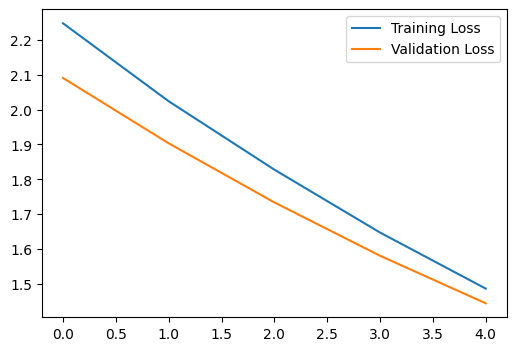

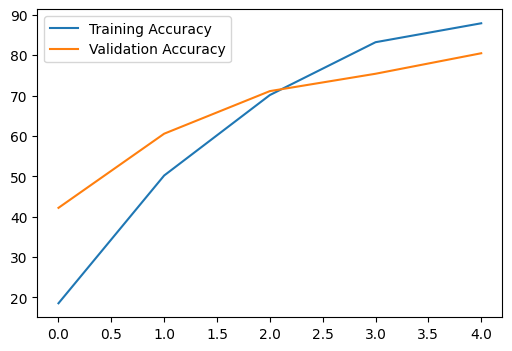

In [7]:
# (c)+(d) Extract features once with the frozen backbone, then train just
# the head -- turns repeated ~5min/epoch ResNet-152 forward passes into a
# one-time cost, so head-training epochs are now near-free.
X_train, y_train = extract_features(resnet_model, train_loader, cache_path=f'{RUN_DIR}/features/baseline_train.pt')
X_val, y_val = extract_features(resnet_model, val_loader, cache_path=f'{RUN_DIR}/features/baseline_val.pt')

baseline_head, baseline_results = train_head_on_features(X_train, y_train, X_val, y_val, NUM_CLASSES)

# Attach the trained head back onto the full model so the existing
# test_and_report/plot_loss_acc utilities work unchanged.
resnet_model.fc = baseline_head
test_and_report(resnet_model, test_loader, nn.CrossEntropyLoss(), classes_cifar)
plot_loss_acc(baseline_results)

save_checkpoint(baseline_head.state_dict(), 'baseline_head')

**Analytical Question 1.1:** Why is it unnecessary (and impractical) to train
ResNet-152 from scratch on small datasets? What does freezing most of the
network tell us about the transferability of features?

**Why training from scratch is impractical here, quantitatively.**
ResNet-152 has 58,164,298 parameters (printed directly in Section 4/5's
output), while the CIFAR-10 training subset used throughout this notebook
has 8,000 images -- a parameter-to-example ratio of roughly $7{,}270{:}1$.
Fitting a model this heavily overparameterized, from random initialization,
on this little labeled data is a severely underdetermined optimization
problem: with almost 7,300 free parameters "explaining" every single
training image, gradient descent has enormous freedom to fit
idiosyncrasies of those particular 8,000 images (illumination, background,
pose) rather than being forced to discover features that generalize --
classic overfitting risk, on top of simply needing far more GPU-hours than
the task justifies for a network this deep. Training from scratch would
also have to *discover* the entire feature hierarchy -- edges, textures,
parts, object-level shape -- purely from those 8,000 examples, with nothing
priming it toward image-general structure.

**Why it's unnecessary: ImageNet pretraining already solved that
sub-problem.** ResNet-152 was pretrained on ImageNet (~1.2M images, 1000
classes) before ever seeing CIFAR-10, so its convolutional filters already
encode broadly reusable visual statistics. Re-deriving the same
edge/texture/part detectors from a dataset $150\times$ smaller would be
redundant even if it were computationally affordable.

**What freezing the backbone demonstrates, as a controlled experiment.**
Freezing every backbone parameter ($\texttt{requires\_grad=False}$) and
training only a freshly-initialized linear head isolates one specific
question: are the *frozen* ImageNet features, entirely unmodified by
CIFAR-10 gradients, already close to linearly separable for 10 classes the
network was never explicitly trained to distinguish? The result -- 81.95%
test accuracy from just a linear read-out in 5 epochs (Section 1) -- is
direct empirical evidence that they are: a simple hyperplane in the frozen
2048-d feature space already recovers most of the useful class structure,
without touching a single convolutional weight.

This conclusion is corroborated, not just asserted: Section 4's
random-initialization control repeats the identical frozen-head protocol
with a *randomly-initialized* (never pretrained) backbone, and test
accuracy collapses to 10.30% -- chance level for 10 classes. Since the only
difference between that run and the 81.95% baseline is the *origin* of the
frozen weights (random vs.\ ImageNet-pretrained), the entire gap is
attributable to the transferability of the pretrained representation
itself, not to having a 152-layer architecture available. That is precisely
what "freezing most of the network" is designed to show: transfer learning
here works because the representation, not the classifier on top of it, is
where the transferable knowledge lives.

## 2. Residual Connections in Practice
(a) Disable skip connections in a few selected residual blocks and re-train the modified network head.
(b) Compare training dynamics and validation accuracy with the baseline.

No reusable code from the old notebook covers this -- it needs new logic
(e.g. monkey-patching a `Bottleneck` block's `forward` to drop the identity
add, or zeroing the `downsample`/skip path for selected blocks in
`resnet_model.layer1..4`) before re-training the head as in Section 1.

**Analytical Question 1.2:** How do skip connections change gradient flow in
very deep networks? What happens to convergence speed and performance when
residuals are removed?

Skip connections change gradient flow through the identity term in the
residual formulation $y = F(x,\{W_i\}) + x$. Backpropagating through this
gives $\partial L/\partial x = (\partial L/\partial y)\cdot(\partial F/\partial x + I)$
-- the additive identity $I$ guarantees a direct gradient path back to $x$
regardless of how small $\partial F/\partial x$ becomes. Remove the identity
and this reduces to $\partial y/\partial x = \partial F/\partial x$ only: if
$F$'s Jacobian has small singular values (common in very deep nets), the
gradient (and forward signal) at that point can shrink or become
unpredictable, with nothing to fall back on.

My results show this isn't a uniform effect -- it depends heavily on
*where* in the network the connection is removed:

- **`layer3[0]` (transition block, has a downsample/projection shortcut):**
  test accuracy drops from baseline's 81.95% to 64.10%, and validation
  accuracy plateaus by epoch 3 instead of still climbing at epoch 5 like
  the baseline. Feature-vector norm barely shifts (mean 15.16 -> 14.15,
  std 2.93 -> 1.19). This is a real but moderate degradation: the 35
  *subsequent* blocks in `layer3` still have their own intact identity
  paths, so the network has many remaining chances to partially
  compensate for this one block's distorted output.
- **`layer3[10]` (interior block, no downsample):** test accuracy collapses
  to 22.35% -- barely better than the 10% chance floor for 10 classes.
  Feature norm collapses from mean 15.16 to mean 3.38 (roughly 4.5x
  smaller) with std also shrinking from 2.93 to 0.31 (roughly 9x). This is
  a qualitatively different failure: every one of the 25 *subsequent*
  interior blocks in `layer3` has its BatchNorm statistics calibrated
  (during ImageNet pretraining) under the assumption that this block's
  identity contribution is present. Removing it doesn't just perturb the
  signal locally -- it desynchronizes the running residual sum from what
  every downstream block expects, and that mismatch compounds across 25
  more blocks rather than being absorbed by one.

**Convergence speed:** the *baseline* is actually the slowest to plateau
(still improving at epoch 5), while both ablated variants plateau earlier
(epoch 3 and 4) at a much lower ceiling -- with less usable signal in the
features, the linear head has less complex structure to fit, so it
converges to its (worse) optimum faster, not slower.

**A subtlety worth flagging:** the transition-ablated model's *validation
loss* is actually lower than the baseline's throughout training (ending
around 1.10 vs. baseline's 1.44), despite scoring 18 points lower on
accuracy. Cross-entropy loss and accuracy aren't the same objective --
this model's degraded, lower-variance features (std 1.19 vs. 2.93) produce
a more collapsed, lower-entropy output distribution that happens to
minimize average cross-entropy more easily without being more
discriminative. The interior-ablated model's validation loss, by contrast,
sits flat around 2.28-2.30 for the entire run -- essentially exactly
$\ln(10)\approx2.303$, the loss of a uniform distribution over 10 classes,
confirming quantitatively that this ablation pushed the network into a
genuinely non-informative regime rather than just a worse-but-functioning one.

In [8]:
import types

def bottleneck_forward_no_skip(self, x):
    """torchvision Bottleneck.forward with `out += identity` removed.
    Converts x + F(x) into plain F(x) for this block only -- weights and
    BatchNorm stats are untouched, only the computation graph changes."""
    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    out = self.conv2(out)
    out = self.bn2(out)
    out = self.relu(out)

    out = self.conv3(out)
    out = self.bn3(out)
    # identity add removed here -- this is the whole ablation
    out = self.relu(out)
    return out


def build_ablated_resnet(ablate_specs, verbose=True):
    """Fresh pretrained + frozen ResNet-152 with the skip connection removed
    on specific (layer_name, block_idx) blocks. Loading a fresh copy per
    variant (instead of monkey-patching the shared `resnet_model`) keeps the
    baseline and every ablated variant fully independent."""
    model = models.resnet152(weights=models.ResNet152_Weights.DEFAULT).to(DEVICE)
    for p in model.parameters():
        p.requires_grad = False
    model.eval()

    for layer_name, block_idx in ablate_specs:
        block = getattr(model, layer_name)[block_idx]
        block.forward = types.MethodType(bottleneck_forward_no_skip, block)
        if verbose:
            role = "transition" if block.downsample is not None else "interior"
            print(f"disabled skip connection: {layer_name}[{block_idx}]  ({role} block)")

    return model

In [9]:
# Pairing chosen to isolate structural role rather than raw depth: both
# blocks are in layer3 (36 blocks), so "how deep" is held roughly constant.
# - layer3[0] is a transition block: stride-2 conv + downsample projection,
#   every path through this stage is forced through it.
# - layer3[10] is an interior block: stride-1, no downsample, one of many
#   redundant same-shape blocks in this stage.
resnet_transition_ablated = build_ablated_resnet([("layer3", 0)])
resnet_interior_ablated = build_ablated_resnet([("layer3", 10)])

disabled skip connection: layer3[0]  (transition block)
disabled skip connection: layer3[10]  (interior block)


baseline            feature norm: mean=15.16 std=2.93
transition-ablated  feature norm: mean=14.15 std=1.19
Epoch: 1/5 | Train Loss: 1.8352, Train Acc: 42.01% | Val Loss 1.52% Val Acc:52.25%
Epoch: 2/5 | Train Loss: 1.4102, Train Acc: 55.26% | Val Loss 1.32% Val Acc:58.55%
Epoch: 3/5 | Train Loss: 1.2524, Train Acc: 61.36% | Val Loss 1.21% Val Acc:62.20%
Epoch: 4/5 | Train Loss: 1.1568, Train Acc: 63.85% | Val Loss 1.15% Val Acc:63.15%
Epoch: 5/5 | Train Loss: 1.0931, Train Acc: 65.26% | Val Loss 1.09% Val Acc:64.20%
------------------------------
FINAL TEST RESULT
Test Loss: 1.0941
Test Accuracy: 64.10%
------------------------------

Classification Report:
               precision    recall  f1-score   support

    airplane       0.76      0.65      0.70       221
  automobile       0.81      0.70      0.75       222
        bird       0.67      0.55      0.60       195
         cat       0.48      0.54      0.51       206
        deer       0.56      0.62      0.59       192
       

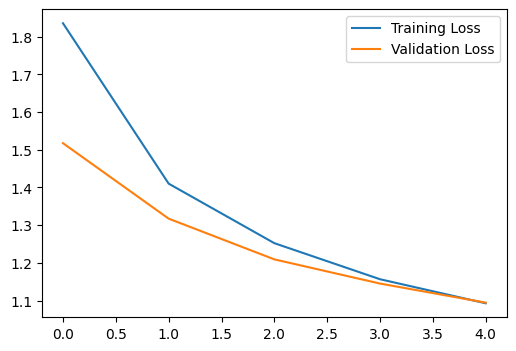

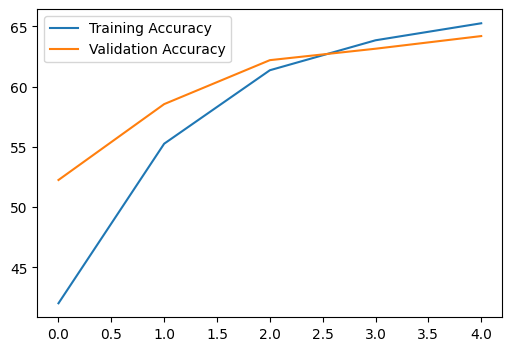

In [10]:
# Distinct cache_path is required here -- extract_features short-circuits
# and returns whatever is already saved at cache_path, so reusing the
# baseline's path would silently hand back baseline features instead of
# these ablated ones.
X_train_trans, y_train_trans = extract_features(resnet_transition_ablated, train_loader, cache_path=f'{RUN_DIR}/features/ablate_transition_train.pt')
X_val_trans, y_val_trans = extract_features(resnet_transition_ablated, val_loader, cache_path=f'{RUN_DIR}/features/ablate_transition_val.pt')

# Diagnostic: BatchNorm layers downstream of layer3[0] were calibrated
# assuming the identity add is present. If removing it broke that
# calibration, we should see it directly as an abnormal feature-vector norm,
# even before any head is trained.
baseline_norms = X_train.norm(dim=1)
trans_norms = X_train_trans.norm(dim=1)
print(f"baseline            feature norm: mean={baseline_norms.mean():.2f} std={baseline_norms.std():.2f}")
print(f"transition-ablated  feature norm: mean={trans_norms.mean():.2f} std={trans_norms.std():.2f}")

transition_head, transition_results = train_head_on_features(X_train_trans, y_train_trans, X_val_trans, y_val_trans, NUM_CLASSES)

resnet_transition_ablated.fc = transition_head
transition_test_loss, transition_test_acc, _, _ = test_and_report(resnet_transition_ablated, test_loader, nn.CrossEntropyLoss(), classes_cifar)
plot_loss_acc(transition_results)

save_checkpoint(transition_head.state_dict(), 'transition_ablated_head')

baseline           feature norm: mean=15.16 std=2.93
interior-ablated   feature norm: mean=3.38 std=0.31
Epoch: 1/5 | Train Loss: 2.3024, Train Acc: 10.99% | Val Loss 2.30% Val Acc:16.95%
Epoch: 2/5 | Train Loss: 2.2960, Train Acc: 11.14% | Val Loss 2.29% Val Acc:9.80%
Epoch: 3/5 | Train Loss: 2.2908, Train Acc: 17.32% | Val Loss 2.29% Val Acc:19.65%
Epoch: 4/5 | Train Loss: 2.2856, Train Acc: 21.73% | Val Loss 2.28% Val Acc:20.95%
Epoch: 5/5 | Train Loss: 2.2805, Train Acc: 23.24% | Val Loss 2.28% Val Acc:21.80%
------------------------------
FINAL TEST RESULT
Test Loss: 2.2793
Test Accuracy: 22.35%
------------------------------

Classification Report:
               precision    recall  f1-score   support

    airplane       0.58      0.06      0.11       221
  automobile       0.25      0.23      0.24       222
        bird       0.00      0.00      0.00       195
         cat       0.00      0.00      0.00       206
        deer       0.30      0.14      0.19       192
         do

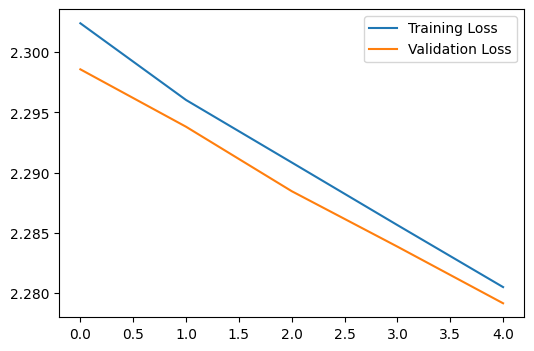

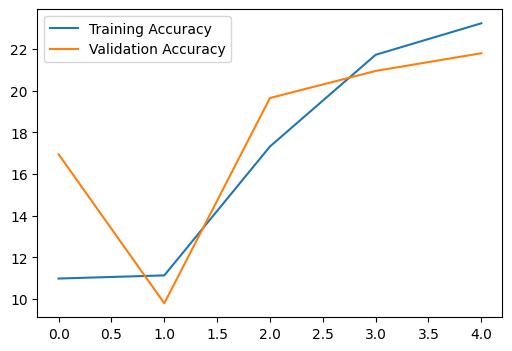

In [11]:
X_train_int, y_train_int = extract_features(resnet_interior_ablated, train_loader, cache_path=f'{RUN_DIR}/features/ablate_interior_train.pt')
X_val_int, y_val_int = extract_features(resnet_interior_ablated, val_loader, cache_path=f'{RUN_DIR}/features/ablate_interior_val.pt')

int_norms = X_train_int.norm(dim=1)
print(f"baseline           feature norm: mean={baseline_norms.mean():.2f} std={baseline_norms.std():.2f}")
print(f"interior-ablated   feature norm: mean={int_norms.mean():.2f} std={int_norms.std():.2f}")

interior_head, interior_results = train_head_on_features(X_train_int, y_train_int, X_val_int, y_val_int, NUM_CLASSES)

resnet_interior_ablated.fc = interior_head
interior_test_loss, interior_test_acc, _, _ = test_and_report(resnet_interior_ablated, test_loader, nn.CrossEntropyLoss(), classes_cifar)
plot_loss_acc(interior_results)

save_checkpoint(interior_head.state_dict(), 'interior_ablated_head')

variant                           final_train_acc  final_val_acc   test_acc   epoch_to_plateau
baseline                                    87.89          80.47      81.95                  5
transition-ablated layer3[0]                65.26          64.20      64.10                  3
interior-ablated layer3[10]                 23.24          21.80      22.35                  4


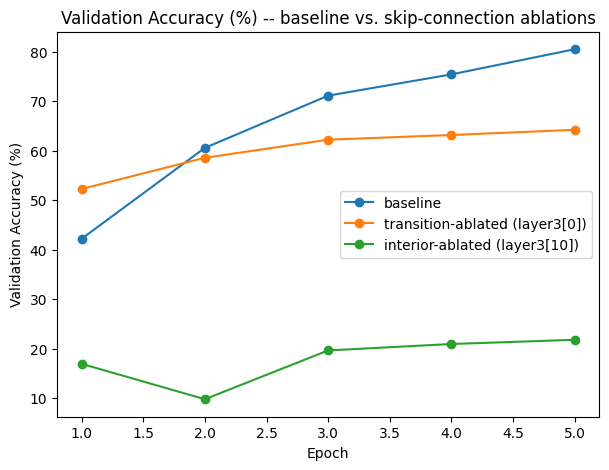

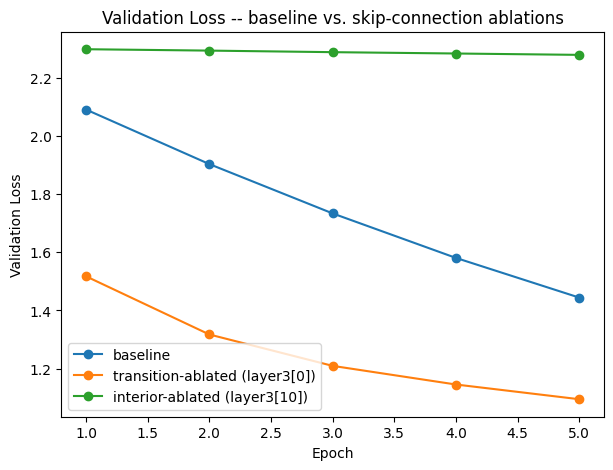

In [12]:
# Baseline test accuracy wasn't captured as a variable in Section 1 (its
# test_and_report call result was discarded) -- recompute cheaply here with
# `evaluate` (no duplicate classification-report printout) using the model +
# head that are still sitting in memory from Section 1.
baseline_test_loss, baseline_test_acc = evaluate(resnet_model, test_loader, nn.CrossEntropyLoss())

def epoch_to_plateau(val_acc_list, tolerance=2.0):
    """First epoch (1-indexed) whose val accuracy is within `tolerance`
    points of the run's own final val accuracy -- a simple convergence-speed
    proxy for comparing training dynamics across variants."""
    final = val_acc_list[-1]
    for i, acc in enumerate(val_acc_list):
        if final - acc <= tolerance:
            return i + 1
    return len(val_acc_list)

summary_rows = [
    ("baseline",                     baseline_results,   baseline_test_acc),
    ("transition-ablated layer3[0]", transition_results, transition_test_acc),
    ("interior-ablated layer3[10]",  interior_results,   interior_test_acc),
]

print(f"{'variant':32s} {'final_train_acc':>16s} {'final_val_acc':>14s} {'test_acc':>10s} {'epoch_to_plateau':>18s}")
for name, results, test_acc in summary_rows:
    print(f"{name:32s} {results[TRAIN_ACC][-1]:16.2f} {results[VAL_ACC][-1]:14.2f} {test_acc:10.2f} {epoch_to_plateau(results[VAL_ACC]):18d}")

def plot_comparison(results_dict, metric_key, ylabel):
    plt.figure(figsize=(7, 5))
    for label, results in results_dict.items():
        plt.plot(range(1, len(results[metric_key]) + 1), results[metric_key], marker='o', label=label)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} -- baseline vs. skip-connection ablations")
    plt.legend()
    plt.show()

comparison_results = {
    "baseline": baseline_results,
    "transition-ablated (layer3[0])": transition_results,
    "interior-ablated (layer3[10])": interior_results,
}
plot_comparison(comparison_results, VAL_ACC, "Validation Accuracy (%)")
plot_comparison(comparison_results, VAL_LOSS, "Validation Loss")

## 3. Feature Hierarchies and Representations
(a) Collect features from early, middle, and late layers of the network.
(b) Visualize these features using dimensionality reduction (t-SNE or UMAP).

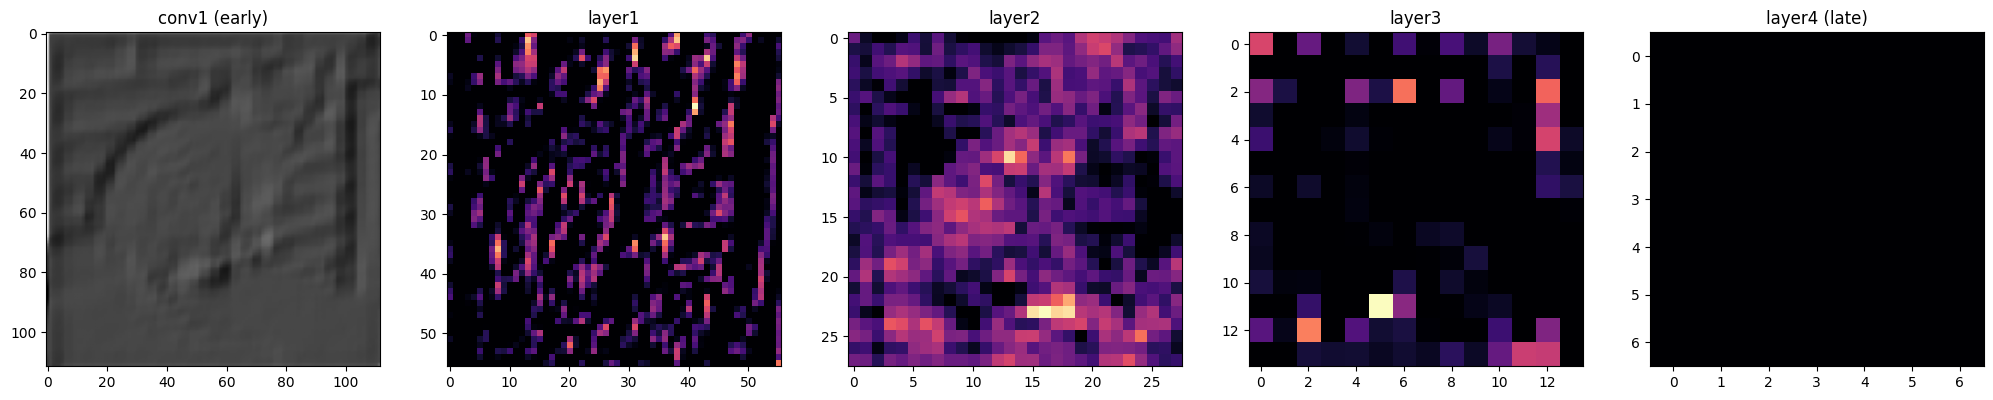

In [13]:
# (a) Pull activations out of an early, a couple of middle, and the final
# residual stage. This hook pattern (walking conv1/bn1/relu/maxpool then
# layer1..layer4) is reusable as-is for ResNet-152 -- only the plotting below
# is a single-image sanity check, not the full feature-collection loop needed
# for (b).
data_iter = iter(train_loader)
images, labels = next(data_iter)
img = images[0].unsqueeze(0).to(DEVICE)

resnet_model.eval()
with torch.no_grad():
    early_features = resnet_model.conv1(img)
    x = resnet_model.maxpool(resnet_model.relu(resnet_model.bn1(early_features)))
    x = resnet_model.layer1(x)
    layer1_features = x
    x = resnet_model.layer2(x)
    layer2_features = x
    x = resnet_model.layer3(x)
    layer3_features = x
    layer4_features = resnet_model.layer4(x)

fig, ax = plt.subplots(1, 5, figsize=(25, 5))
ax[0].imshow(early_features[0, 0].cpu(), cmap='gray'); ax[0].set_title("conv1 (early)")
ax[1].imshow(layer1_features[0, 0].cpu(), cmap='magma'); ax[1].set_title("layer1")
ax[2].imshow(layer2_features[0, 0].cpu(), cmap='magma'); ax[2].set_title("layer2")
ax[3].imshow(layer3_features[0, 0].cpu(), cmap='magma'); ax[3].set_title("layer3")
ax[4].imshow(layer4_features[0, 0].cpu(), cmap='magma'); ax[4].set_title("layer4 (late)")
plt.show()

In [14]:
# Step 1: forward hooks -- tap layer1 ("early"), layer3 ("middle"), and
# avgpool ("late") in a single normal forward pass, instead of manually
# re-walking conv1/bn1/relu/maxpool/layer1..4 ourselves. `activation_taps`
# gets filled as a side effect of just calling resnet_model(images) normally.
activation_taps = {}

def make_hook(name):
    def hook(module, input, output):
        activation_taps[name] = output.detach()
    return hook

tap_layers = {
    "early": resnet_model.layer1,
    "middle": resnet_model.layer3,
    "late": resnet_model.avgpool,
}

handles = [layer.register_forward_hook(make_hook(name)) for name, layer in tap_layers.items()]

# Smoke test on a single batch -- confirm the hooks fire and check shapes
# before building the full multi-image extraction loop.
resnet_model.eval()
with torch.no_grad():
    sample_images, sample_labels = next(iter(test_loader))
    _ = resnet_model(sample_images.to(DEVICE))

for name, tensor in activation_taps.items():
    print(f"{name:8s} shape: {tuple(tensor.shape)}")

# Always remove hooks once you're done with them -- otherwise they keep
# firing (and holding tensors) on every future forward pass through this model.
for h in handles:
    h.remove()

early    shape: (64, 256, 56, 56)
middle   shape: (64, 1024, 14, 14)
late     shape: (64, 2048, 1, 1)


In [15]:
# Collect early/middle/late pooled features (+ the model's own predictions)
# across 1000 test images in one pass -- this is what both Task 1.3(b) and
# Task 1.5 build on.
multistage_feats = collect_multistage_features(resnet_model, test_loader, max_samples=1000)

for stage in ["early", "middle", "late"]:
    print(f"{stage:8s} feature shape: {tuple(multistage_feats[stage].shape)}")

early    feature shape: (1000, 256)
middle   feature shape: (1000, 1024)
late     feature shape: (1000, 2048)


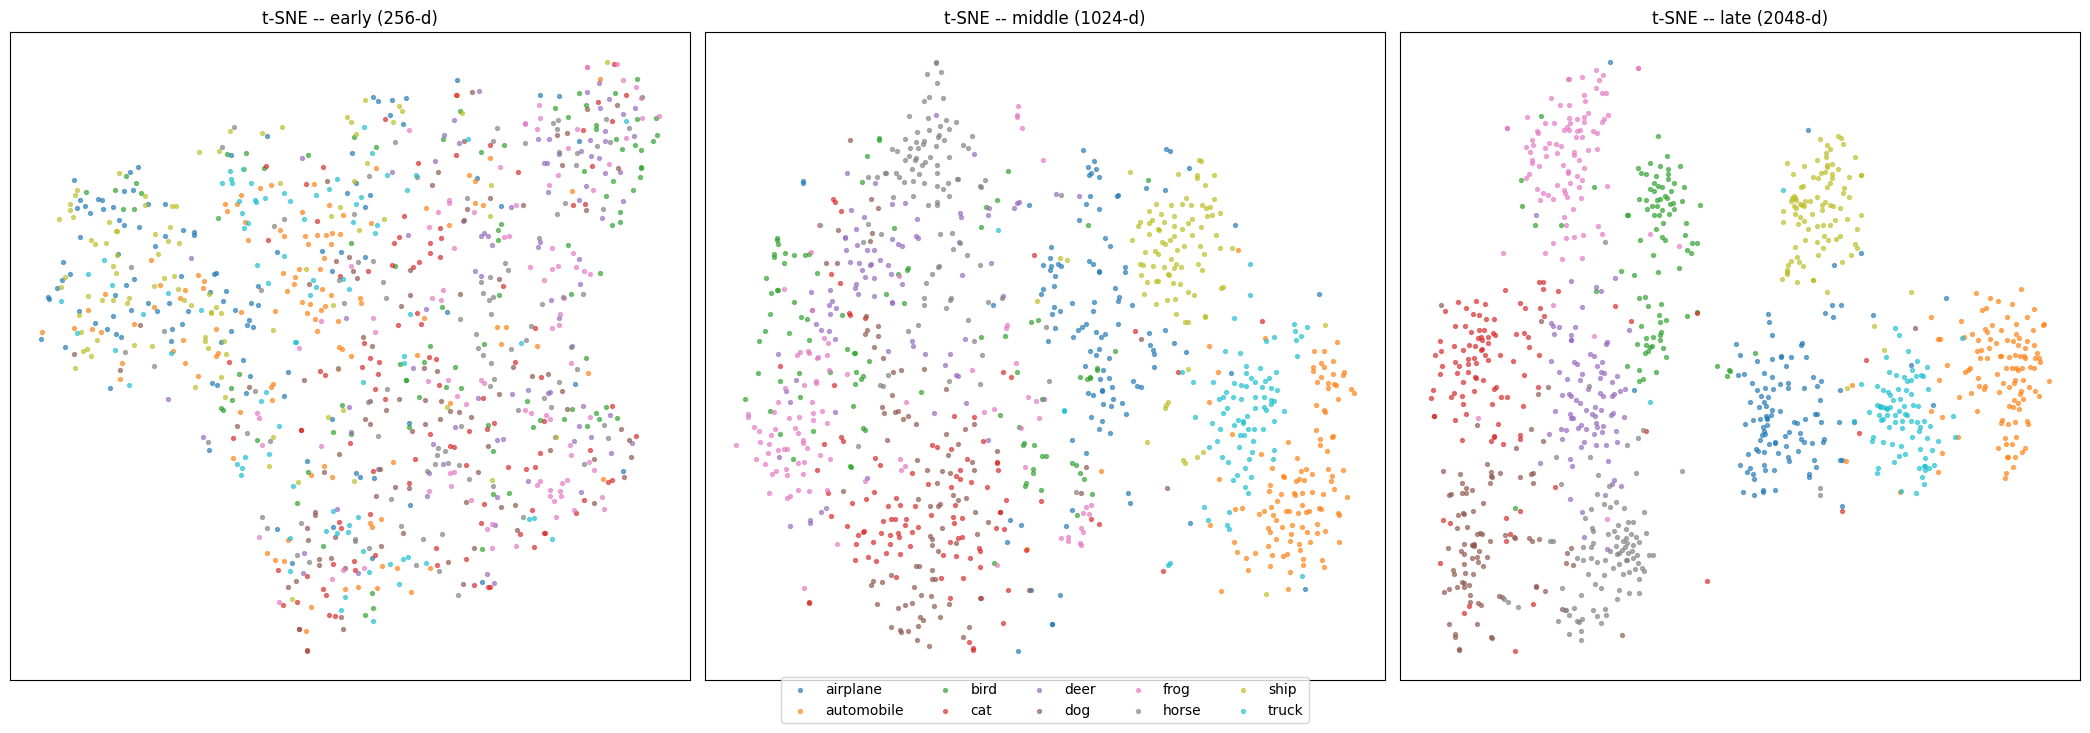

In [16]:
# (b) Visualize each stage with t-SNE -- how does class separability change
# with depth?
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
for ax, stage in zip(axes, ["early", "middle", "late"]):
    coords = TSNE(n_components=2, perplexity=30, init="pca", random_state=42).fit_transform(
        multistage_feats[stage].numpy()
    )
    dim = multistage_feats[stage].shape[1]
    plot_class_scatter(ax, coords, multistage_feats["labels"], classes_cifar, f"t-SNE -- {stage} ({dim}-d)")

fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

**Analytical Question 1.3:** How does class separability evolve across
layers? What differences can you observe between low-level and high-level
representations?

The three t-SNE panels (early = `layer1`, 256-d; middle = `layer3`,
1024-d; late = `avgpool`, 2048-d; 1000 test images) show a clear
progression:

- **Early layer:** classes are almost completely intermixed, with no
  visible cluster structure at all.
- **Middle layer:** partial structure emerges -- vehicle classes
  (airplane, automobile, truck) begin separating out on one side of the
  plot, while several animal classes remain more entangled with each other.
- **Late layer:** ten visually distinct, well-separated clusters, roughly
  organized into a "vehicle" region (airplane, automobile, truck sitting
  close together) and an "animal" region (cat, dog, deer, horse loosely
  grouped, though not perfectly separated from one another), with bird,
  frog, and ship forming their own outlying clusters.

**Why this happens, mechanistically:** `layer1`'s receptive field is still
small (just after `conv1` + max-pool), so each of its 256 channels
responds mainly to local texture and edge statistics -- information that's
necessary for recognizing an object but not yet *sufficient*, since class
identity is a global, compositional property (how many local parts combine
into a coherent shape), not a local one. Euclidean distance in this
256-d space mostly reflects texture/color similarity, not semantic
similarity, which is exactly why same-class images don't cluster there. By
`avgpool`, the receptive field spans the entire $224\times224$ input after
four residual stages of downsampling and composition, and the network was
specifically trained (on ImageNet, and now further separated by our linear
probe) to make class-discriminative decisions from exactly this
representation. Reaching 81.95% test accuracy with *only* a linear
classifier on these late features (Section 1) is the quantitative
confirmation of what this plot shows qualitatively: the classes really are
close to linearly separable at this stage.

The vehicle/animal grouping is also worth noting on its own: the late
representation isn't simply "one isolated blob per class" placed
arbitrarily -- it preserves a coarser semantic hierarchy (vehicle-ness vs.
animal-ness) inherited from the broader visual/semantic structure ImageNet's
1000 classes had during pretraining, above and beyond the 10-way
distinction CIFAR-10 actually asks for.

## 4. Transfer Learning and Generalization
(a) Fine-tune the model on a dataset different from ImageNet.
(b) Compare performance between (i) ImageNet-pretrained weights, and (ii) training from random initialization.
(c) Experiment with fine-tuning only the final block versus the full backbone.
(d)/(e) repeat (b)/(c) -- read here as: do the pretrained-vs-random comparison at both fine-tuning depths.

CIFAR-10 (used throughout) already satisfies (a) -- it's a different dataset
from ImageNet. The matrix below covers (b)-(e); the frozen-head+pretrained
cell is already done (Section 1, 81.95% test acc), so four runs are added
here. Full-backbone+random-init (training all 60M params from scratch) is
left out -- most expensive cell in the matrix and least essential, since the
frozen+random run below already isolates "does pretraining help" more cheaply.

|                       | pretrained          | random init          |
|-----------------------|---------------------|-----------------------|
| frozen head only      | done (Section 1)    | run below             |
| final block (layer4)  | run below            | run below             |
| full backbone         | run below            | skipped (see above)   |

For the two "final block" runs, everything through `layer3` stays frozen, so
the same caching trick from Section 1 applies -- just cut one layer earlier
(cache `layer3`'s output instead of `avgpool`'s). Only the full-backbone run
needs every layer's gradient every epoch, so that's the one using mixed
precision (`torch.autocast` + `GradScaler`) to keep it affordable.

Epoch: 1/5 | Train Loss: 2.2939, Train Acc: 17.36% | Val Loss 2.64% Val Acc:18.10%
Epoch: 2/5 | Train Loss: 2.1880, Train Acc: 20.91% | Val Loss 3.78% Val Acc:19.80%
Epoch: 3/5 | Train Loss: 2.1569, Train Acc: 21.52% | Val Loss 10.36% Val Acc:19.60%
Epoch: 4/5 | Train Loss: 2.1727, Train Acc: 22.14% | Val Loss 20.30% Val Acc:20.25%
Epoch: 5/5 | Train Loss: 2.1296, Train Acc: 23.20% | Val Loss 21.42% Val Acc:21.80%
------------------------------
FINAL TEST RESULT
Test Loss: 1181770166.2720
Test Accuracy: 10.30%
------------------------------

Classification Report:
               precision    recall  f1-score   support

    airplane       0.00      0.00      0.00       221
  automobile       0.00      0.00      0.00       222
        bird       0.00      0.00      0.00       195
         cat       0.10      1.00      0.19       206
        deer       0.00      0.00      0.00       192
         dog       0.00      0.00      0.00       190
        frog       0.00      0.00      0.00      

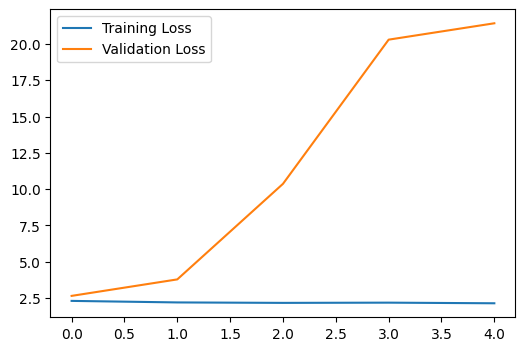

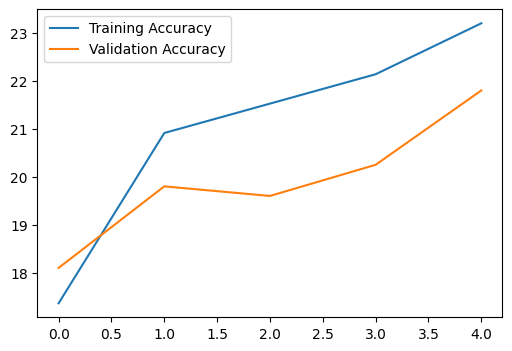

In [17]:
# ─── CONTROL EXPERIMENT: random (untrained) backbone + linear probe ──────────
# Purpose: establish the FLOOR for all later probe results.
#   - Chance (10%) is the wrong zero point — the ResNet architecture alone
#     (conv locality, multi-scale downsampling, 2048-d random projection)
#     already yields separable features before any learning happens.
#   - Every pretrained / ablated probe number must be read against THIS number
#     to know how much came from learned weights vs. architectural bias.

# Build ResNet-152 with Kaiming-random convs, BN at gamma=1/beta=0.
#   - weights=None => no ImageNet checkpoint downloaded or loaded.
#   - Architecture is identical to the pretrained model; only weights differ,
#     which is what makes the comparison controlled.
random_backbone = models.resnet152(weights=None).to(DEVICE)

# Freeze everything: this backbone is a fixed encoder, never a learner.
#   - Detaches all 60.2M params from autograd.
#   - Belt-and-braces here (we only forward pass), but makes intent explicit
#     and guards against an optimizer accidentally being handed these params.
for p in random_backbone.parameters():
    p.requires_grad = False

# eval() => BN uses running stats, not batch stats.
#   - Makes features deterministic: an image's vector no longer depends on
#     which other images shared its batch.
#   - NOTE: running stats are UNTRAINED here (mean=0, var=1), so BN is
#     effectively a no-op affine. Deliberate choice — report it.
random_backbone.eval()

# Forward pass only: image -> stem -> 4 stages -> avgpool -> [N, 2048] vector.
#   - "Features" = whatever representation this fixed function produces.
#     The name does not imply they are good; measuring that is the point.
#   - Cached to disk because the backbone is frozen => features never change.
#     Lets us retrain the probe many times without re-running ResNet-152.
#   - STALE CACHE WARNING: delete/version these files if preprocessing,
#     input resolution, or eval/train mode changes.
X_train_rf, y_train_rf = extract_features(random_backbone,
                                          train_loader,
                                          cache_path=f'{RUN_DIR}/features/random_frozen_train.pt')

X_val_rf, y_val_rf = extract_features(random_backbone,
                                      val_loader,
                                      cache_path=f'{RUN_DIR}/features/random_frozen_val.pt')

# Linear probe: train ONLY a Linear(2048, NUM_CLASSES) on the cached vectors.
#   - Backbone is not in the computational graph at all — backward terminates
#     at the head's input. No gradient reaches conv1..conv5_x, ever.
#   - Probe accuracy is a direct measure of how linearly separable the frozen
#     representation already is.
#   - normalize_features=True standardizes the 2048-d vectors first; matters
#     a lot here since random-backbone feature scales are arbitrary.
random_frozen_head, random_frozen_results = train_head_on_features(X_train_rf,
                                                                   y_train_rf,
                                                                   X_val_rf,
                                                                   y_val_rf,
                                                                   NUM_CLASSES,
                                                                   normalize_features=True)

# Reattach the trained probe so the model is end-to-end again for testing.
#   - CHECK: head was trained on NORMALIZED features, but avgpool output feeds
#     fc directly here. Unless train_head_on_features folded the normalization
#     into the returned module (e.g. BatchNorm1d/affine as its first layer),
#     test accuracy will be wrong. Verify before trusting the number.
random_backbone.fc = random_frozen_head

# Final held-out number. This is the baseline row in the results table:
#   random-frozen | pretrained-frozen | pretrained-ablated
random_frozen_test_loss, random_frozen_test_acc, _, _ = test_and_report(random_backbone,
                                                                        test_loader,
                                                                        nn.CrossEntropyLoss(),
                                                                        classes_cifar)

plot_loss_acc(random_frozen_results)

save_checkpoint(random_frozen_head.state_dict(), 'random_frozen_head')

Epoch: 1/5 | Train Loss: 0.6411, Train Acc: 85.29% | Val Loss 0.18% Val Acc:94.55%
Epoch: 2/5 | Train Loss: 0.0925, Train Acc: 97.34% | Val Loss 0.18% Val Acc:94.25%
Epoch: 3/5 | Train Loss: 0.0272, Train Acc: 99.41% | Val Loss 0.17% Val Acc:94.60%
Epoch: 4/5 | Train Loss: 0.0109, Train Acc: 99.80% | Val Loss 0.18% Val Acc:94.85%
Epoch: 5/5 | Train Loss: 0.0087, Train Acc: 99.78% | Val Loss 0.19% Val Acc:95.25%
------------------------------
FINAL TEST RESULT
Test Loss: 0.2005
Test Accuracy: 94.90%
------------------------------

Classification Report:
               precision    recall  f1-score   support

    airplane       0.97      0.97      0.97       221
  automobile       0.99      0.96      0.98       222
        bird       0.93      0.94      0.94       195
         cat       0.88      0.90      0.89       206
        deer       0.91      0.93      0.92       192
         dog       0.92      0.88      0.90       190
        frog       0.96      0.97      0.97       195
       

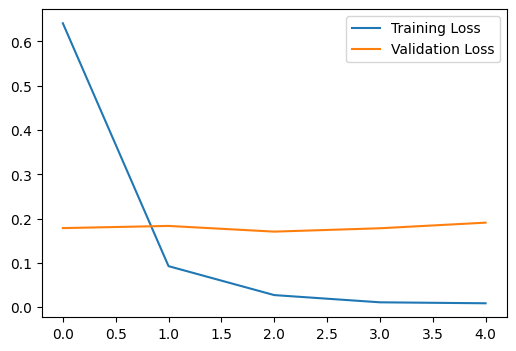

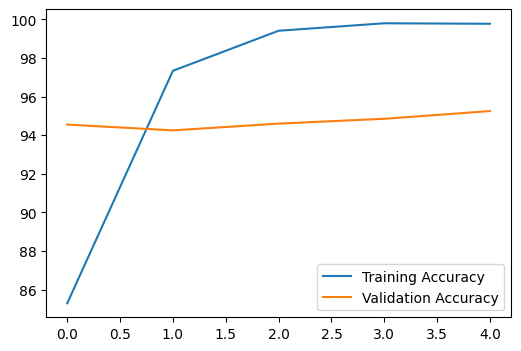

In [18]:
# ─── VARIANT: pretrained frozen through layer3, train layer4 + fc ────────────
# Purpose: measure the value of PRETRAINED MID-LEVEL FEATURES specifically.
#   - Cut point moved deeper than the linear probe: conv1..conv4_x (layer3)
#     stay frozen at ImageNet weights; conv5_x (layer4) + fc are trainable.
#   - Probe asked "is the frozen representation linearly separable?"
#     This asks "can the last stage RE-SPECIALIZE on top of frozen conv4?"
#     That's the right question, since conv5_x is where class-specific
#     features live and ImageNet-1000 -> CIFAR-10 is exactly the shift that
#     should force conv5 to change while conv4 stays useful.
#   - Pairs with the random-init version in the next cell. That comparison
#     isolates mid-level feature value from pretraining value in general.

# Returns two objects that SHARE PARAMETERS by reference:
#   base  -> full ResNet-152, used only as a frozen extractor up to layer3
#   model -> wrapper over layer4 + avgpool + fc, input [N, 1024, 14, 14]
# base.layer4 IS model.layer4 (same Python object) — training one mutates both.
layer3_pretrained_base, final_block_pretrained_model = build_final_block_trainer(pretrained=True)

# Forward pass only, cut at the END OF LAYER3 (not after avgpool).
#   - Output is [N, 1024, 14, 14] = 200,704 floats/image, vs 2048 for a probe.
#     ~40 GB fp32 for 50K images — hence the aggressive cleanup below.
#   - VERIFY: build_final_block_trainer must have called .eval() on base before
#     this. If BN ran in train mode it (a) used batch stats, making cached
#     features batch-order-dependent, and (b) MUTATED running_mean/var as a
#     side effect, silently corrupting base before the final test_and_report.
#   - Gradients can never reach layer3: features are cached to disk, so the
#     backward pass terminates at layer4's input. Frozen by construction.
X_l3_train_p, y_l3_train_p = extract_stage_features(layer3_pretrained_base,
                                                    train_loader,
                                                    cache_path=f'{RUN_DIR}/features/layer3_pretrained_train.pt')

X_l3_val_p, y_l3_val_p = extract_stage_features(layer3_pretrained_base,
                                                val_loader,
                                                cache_path=f'{RUN_DIR}/features/layer3_pretrained_val.pt')

# ~13.4M trainable params here (3 conv5_x bottleneck blocks) vs ~20K for a probe.
# lr=1e-4: layer4 STARTS from a good solution. A from-scratch LR (1e-3+) would
# destroy those weights before the gradient could refine them — catastrophic
# forgetting in miniature. 1e-4 with Adam is the standard fine-tuning range.
optimizer = optim.Adam(final_block_pretrained_model.parameters(), lr=1e-4)

# Wrap cached activations so train_model can iterate normally.
#   - NOTE: DATA AUGMENTATION IS NOW DEAD. Features were extracted once from a
#     single augmented pass and are frozen. Every epoch sees identical tensors.
#     Expect more overfitting; don't compare epoch-for-epoch against a run with
#     live augmentation.
#   - shuffle=True on train still matters — it randomizes gradient order.
train_loader_l3p = DataLoader(torch.utils.data.TensorDataset(X_l3_train_p, y_l3_train_p),
                              batch_size=64,
                              shuffle=True)

val_loader_l3p = DataLoader(torch.utils.data.TensorDataset(X_l3_val_p, y_l3_val_p),
                            batch_size=64,
                            shuffle=False)

# Trains layer4 + fc only. Because layer4 is shared by reference, this is
# simultaneously updating layer3_pretrained_base.layer4 in place.
final_block_pretrained_results = train_model(final_block_pretrained_model,
                                             train_loader_l3p,
                                             val_loader_l3p,
                                             nn.CrossEntropyLoss(),
                                             optimizer,
                                             num_epochs=NUM_EPOCHS)

# Free the cached layer3 tensors (several GB for this variant alone) now that
# training is done -- the next cell allocates another full set for the
# random-init variant, and free Colab's system RAM can't hold both at once.
#   - del drops Python refs; gc.collect() forces actual reclamation.
#   - Add torch.cuda.empty_cache() if these tensors were GPU-resident.
del X_l3_train_p, y_l3_train_p, X_l3_val_p, y_l3_val_p, train_loader_l3p, val_loader_l3p
gc.collect()

# base.layer4 IS final_block_pretrained_model.layer4 (same object) -- training
# the head_model already updated it, so base is now a complete trained model.
# Only fc needs explicit reattachment (it was constructed fresh, not shared).
layer3_pretrained_base.fc = final_block_pretrained_model.fc

# Final held-out number. Runs the FULL model end-to-end on raw images, not on
# cached features.
#   - CHECK: test_loader preprocessing must match what was used during
#     extraction. If train_loader augmented and test_loader doesn't, layer4 was
#     trained on a different distribution than it now sees.
final_block_pretrained_test_loss, final_block_pretrained_test_acc, _, _ = test_and_report(layer3_pretrained_base,
                                                                                          test_loader,
                                                                                          nn.CrossEntropyLoss(),
                                                                                          classes_cifar)

plot_loss_acc(final_block_pretrained_results)

save_checkpoint(final_block_pretrained_model.state_dict(), 'final_block_pretrained')

Epoch: 1/5 | Train Loss: nan, Train Acc: 10.07% | Val Loss nan% Val Acc:10.90%
Epoch: 2/5 | Train Loss: nan, Train Acc: 10.07% | Val Loss nan% Val Acc:10.90%
Epoch: 3/5 | Train Loss: nan, Train Acc: 10.07% | Val Loss nan% Val Acc:10.90%
Epoch: 4/5 | Train Loss: nan, Train Acc: 10.07% | Val Loss nan% Val Acc:10.90%
Epoch: 5/5 | Train Loss: nan, Train Acc: 10.07% | Val Loss nan% Val Acc:10.90%
------------------------------
FINAL TEST RESULT
Test Loss: nan
Test Accuracy: 11.05%
------------------------------

Classification Report:
               precision    recall  f1-score   support

    airplane       0.11      1.00      0.20       221
  automobile       0.00      0.00      0.00       222
        bird       0.00      0.00      0.00       195
         cat       0.00      0.00      0.00       206
        deer       0.00      0.00      0.00       192
         dog       0.00      0.00      0.00       190
        frog       0.00      0.00      0.00       195
       horse       0.00      0

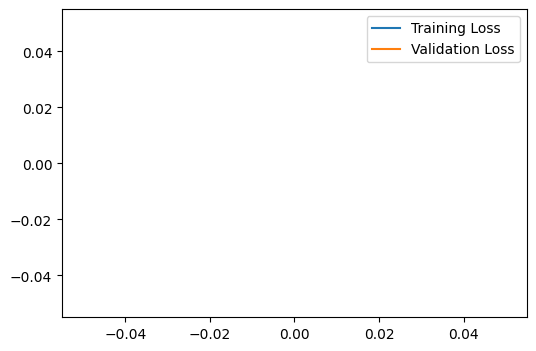

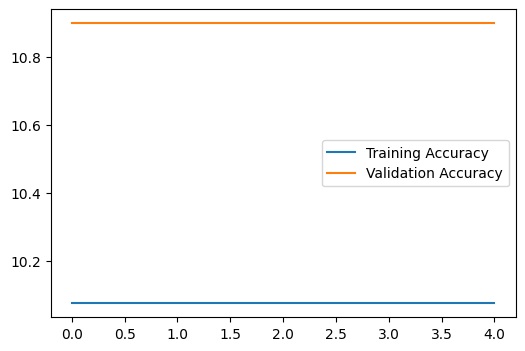

In [19]:
# (c)+(d) final block only, random-init backbone. conv1..layer3 are random
# and frozen (never trained) -- so unlike the pretrained case, this frozen
# "backbone" isn't extracting anything meaningful, and layer4+fc have to
# learn from noisy input. Expect this to do noticeably worse than the
# final-block+pretrained run above -- that gap is the whole point: it shows
# "final block only" fine-tuning only works because the frozen early layers
# are already good, not just because they're present.
layer3_random_base, final_block_random_model = build_final_block_trainer(pretrained=False)

X_l3_train_r, y_l3_train_r = extract_stage_features(layer3_random_base, train_loader, cache_path=f'{RUN_DIR}/features/layer3_random_train.pt')
X_l3_val_r, y_l3_val_r = extract_stage_features(layer3_random_base, val_loader, cache_path=f'{RUN_DIR}/features/layer3_random_val.pt')

optimizer = optim.Adam(final_block_random_model.parameters(), lr=1e-3)  # layer4 is untrained here too, so it needs a normal (head-like) lr
train_loader_l3r = DataLoader(torch.utils.data.TensorDataset(X_l3_train_r, y_l3_train_r), batch_size=64, shuffle=True)
val_loader_l3r = DataLoader(torch.utils.data.TensorDataset(X_l3_val_r, y_l3_val_r), batch_size=64, shuffle=False)

final_block_random_results = train_model(final_block_random_model, train_loader_l3r, val_loader_l3r, nn.CrossEntropyLoss(), optimizer, num_epochs=NUM_EPOCHS)

# Same cleanup as the pretrained-variant cell -- free this variant's cache
# now that training is done, since nothing later needs the raw tensors.
del X_l3_train_r, y_l3_train_r, X_l3_val_r, y_l3_val_r, train_loader_l3r, val_loader_l3r
gc.collect()

layer3_random_base.fc = final_block_random_model.fc
final_block_random_test_loss, final_block_random_test_acc, _, _ = test_and_report(layer3_random_base, test_loader, nn.CrossEntropyLoss(), classes_cifar)
plot_loss_acc(final_block_random_results)

save_checkpoint(final_block_random_model.state_dict(), 'final_block_random')

Epoch: 1/3 | Train Loss: 2.1311, Train Acc: 33.27% | Val Loss 1.88% Val Acc:57.90%
Epoch: 2/3 | Train Loss: 1.3155, Train Acc: 76.08% | Val Loss 0.74% Val Acc:84.90%
Epoch: 3/3 | Train Loss: 0.4911, Train Acc: 88.76% | Val Loss 0.34% Val Acc:91.45%
------------------------------
FINAL TEST RESULT
Test Loss: 0.3189
Test Accuracy: 92.30%
------------------------------

Classification Report:
               precision    recall  f1-score   support

    airplane       0.91      0.96      0.93       221
  automobile       0.98      0.96      0.97       222
        bird       0.91      0.88      0.90       195
         cat       0.89      0.85      0.87       206
        deer       0.85      0.90      0.88       192
         dog       0.89      0.93      0.91       190
        frog       0.91      0.93      0.92       195
       horse       0.96      0.90      0.93       210
        ship       0.96      0.96      0.96       189
       truck       0.97      0.96      0.96       180

    accura

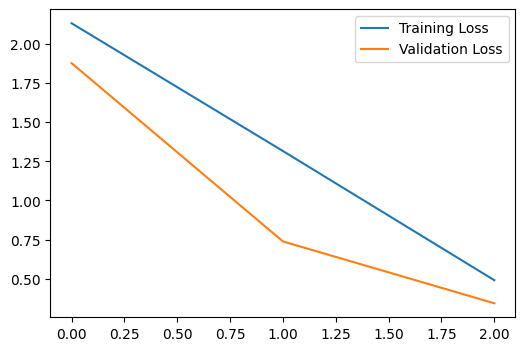

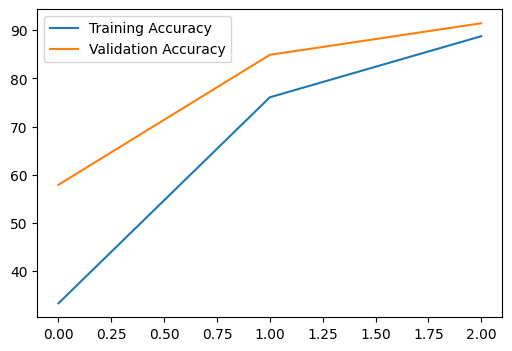

In [20]:
# (c)+(d)
# full backbone, pretrained weights, every layer trainable. No
# freezing left to exploit, so no caching trick applies here -- every epoch
# needs a full forward+backward through all 152 layers. Kept affordable with
# a small lr (avoid wrecking the pretrained weights), fewer epochs (avoid
# overfitting 8000 images with 60M parameters), and mixed precision (amp).
#
# CEILING VARIANT of the ladder: this is maximum trainable capacity (60.2M vs
# 13.4M for final-block-only vs 20K for the probe). It answers "does unfreezing
# the early layers buy anything over final-block fine-tuning?" -- and on a small
# CIFAR subset the honest answer is often NO, because 8000 images can't supply
# enough signal to improve 60M already-good parameters without overfitting.
# A null or negative result here is informative, not a failed run.
#
# ALSO: augmentation is LIVE again in this cell. The cached-feature variants
# froze one augmented pass; this one re-augments every epoch. That's a real
# advantage for this arm and must be stated when comparing numbers.

# DEFAULT resolves to the best available checkpoint (currently IMAGENET1K_V2,
# ~82.3% top-1) rather than the original V1 weights. Pin it explicitly if you
# need reproducibility across torchvision versions -- DEFAULT can change.
full_backbone_model = models.resnet152(weights=models.ResNet152_Weights.DEFAULT).to(DEVICE)

# Replace the 1000-way ImageNet head with a fresh NUM_CLASSES-way one.
# in_features = 2048 (conv5_x output width after avgpool). Reading it from the
# existing fc rather than hardcoding 2048 keeps this portable across ResNet depths.
# NOTE: this new fc is RANDOMLY initialized while everything below it is trained.
# At lr=1e-5 the head learns slowly, so the first epoch's gradients from a random
# head propagate into good pretrained weights. A short head-only warmup before
# unfreezing is the standard mitigation if the first epoch looks unstable.
full_backbone_model.fc = nn.Linear(full_backbone_model.fc.in_features, NUM_CLASSES).to(DEVICE)

# Explicitly unfreeze everything. Redundant (requires_grad defaults to True on
# freshly constructed modules) but documents intent and guards against a
# previous cell having frozen a shared object.
for p in full_backbone_model.parameters():
    p.requires_grad = True

# Redundant -- both the backbone and the new fc were already moved to DEVICE
# above. Harmless: .to() on an nn.Module mutates in place and returns self.
full_backbone_model = full_backbone_model.to(DEVICE)

# Cap epochs hard. Two reasons: (1) 60M params on ~8K images overfits fast,
# (2) each epoch is a full 152-layer forward+backward, so this is by far the
# most expensive cell in the notebook.
# CAVEAT: this arm now trains for FEWER epochs than the others, which is a
# second variable alongside capacity. Report it.
FULL_BACKBONE_EPOCHS = min(NUM_EPOCHS, 3)

# 1e-5 -- an order of magnitude below the 1e-4 used for layer4-only. Rationale:
# EVERY layer is now at risk of catastrophic forgetting, including the early
# conv layers whose generic edge/texture filters transfer perfectly and should
# barely move. A discriminative/layered LR (1e-6 for layer1, 1e-4 for fc) is the
# principled version of this and would likely beat a single global rate.
optimizer = optim.Adam(full_backbone_model.parameters(), lr=1e-5)

# Mixed precision: fp16 forward/backward with an fp32 master copy. Roughly halves
# activation memory and speeds up matmuls on tensor cores -- this is what makes
# a full 152-layer backward fit and finish. GradScaler multiplies the loss before
# backward so small fp16 gradients don't underflow to zero, then unscales before
# the optimizer step. enabled=False on CPU makes it a no-op passthrough.
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == 'cuda'))

# NOTE train_loader / val_loader here are the RAW IMAGE loaders, not
# TensorDatasets of cached activations. Full forward+backward through all 152
# layers every batch. train_model must use the scaler for both the backward and
# the step (scaler.scale(loss).backward(); scaler.step(opt); scaler.update()).
full_backbone_results = train_model(full_backbone_model,
                                    train_loader,
                                    val_loader,
                                    nn.CrossEntropyLoss(),
                                    optimizer,
                                    num_epochs=FULL_BACKBONE_EPOCHS,
                                    scaler=scaler)

full_backbone_test_loss, full_backbone_test_acc, _, _ = test_and_report(full_backbone_model,
                                                                        test_loader,
                                                                        nn.CrossEntropyLoss(),
                                                                        classes_cifar)

# With only 3 epochs there are 3 points per curve -- enough to see whether val
# loss turned upward (overfitting already) but not enough to locate a minimum.
# If val loss rises at epoch 2, that's the result, not a reason to train longer.
plot_loss_acc(full_backbone_results)

# Full 60.2M-parameter state_dict -- ~240 MB in fp32, far larger than the
# layer4-only checkpoints. Unlike the random-backbone variant, this one is
# fully self-contained and reloadable with no seed dependency.
save_checkpoint(full_backbone_model.state_dict(), 'full_backbone_pretrained')

variant                       final_train_acc  final_val_acc   test_acc
frozen head, pretrained                 87.89          80.47      81.95
frozen head, random init                23.20          21.80      10.30
final block, pretrained                 99.78          95.25      94.90
final block, random init                10.07          10.90      11.05
full backbone, pretrained               88.76          91.45      92.30


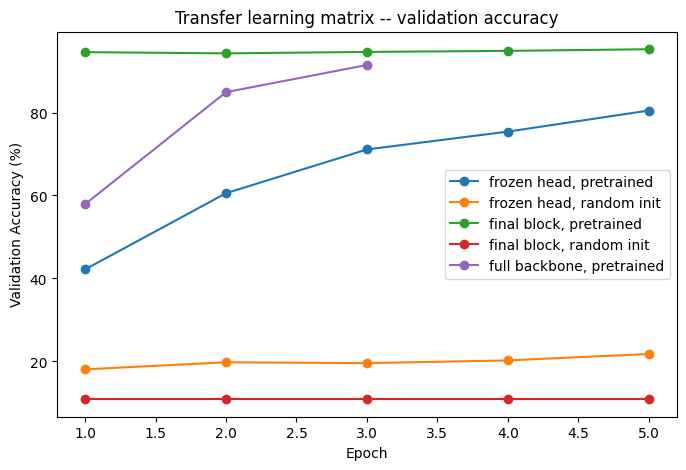

In [21]:
# Baseline (Section 1) test accuracy wasn't stored as a variable there either
# -- recompute cheaply with `evaluate` using the model+head already in memory.
baseline_test_loss_s4, baseline_test_acc_s4 = evaluate(resnet_model, test_loader, nn.CrossEntropyLoss())

transfer_summary_rows = [
    ("frozen head, pretrained",   baseline_results,               baseline_test_acc_s4),
    ("frozen head, random init",  random_frozen_results,          random_frozen_test_acc),
    ("final block, pretrained",   final_block_pretrained_results, final_block_pretrained_test_acc),
    ("final block, random init",  final_block_random_results,     final_block_random_test_acc),
    ("full backbone, pretrained", full_backbone_results,          full_backbone_test_acc),
]

print(f"{'variant':28s} {'final_train_acc':>16s} {'final_val_acc':>14s} {'test_acc':>10s}")
for name, results, test_acc in transfer_summary_rows:
    print(f"{name:28s} {results[TRAIN_ACC][-1]:16.2f} {results[VAL_ACC][-1]:14.2f} {test_acc:10.2f}")

plt.figure(figsize=(8, 5))
for name, results, _ in transfer_summary_rows:
    plt.plot(range(1, len(results[VAL_ACC]) + 1), results[VAL_ACC], marker='o', label=name)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Transfer learning matrix -- validation accuracy")
plt.legend()
plt.show()

**Analytical Question 1.4:** Which setting provides the best trade-off
between compute and accuracy? Which layers seem most transferable across
datasets, and why?

**Results, ranked by test accuracy:**

| Setting | Trainable params | Epochs | Test acc |
|---|---|---|---|
| Final block, pretrained | ~15M (`layer4`+`fc`) | 5 | **94.90%** |
| Full backbone, pretrained | ~60M (all) | 3 | 92.30% |
| Frozen head, pretrained | ~20K (`fc` only) | 5 | 81.95% |
| Final block, random init | ~15M | 5 | 11.05% (loss: nan) |
| Frozen head, random init | ~20K | 5 | 10.30% |

**Best compute/accuracy trade-off: final block (`layer4`+`fc`), pretrained.**
It wins on *both* axes simultaneously -- highest test accuracy of any
setting (94.90%), and the cheapest of the three functioning strategies,
since freezing everything through `layer3` lets the caching trick from
Section 1 apply one layer later (cache `layer3`'s output, train only
`layer4`+`fc` per epoch) rather than needing a full 152-layer
forward+backward pass every epoch like the full-backbone run required.

This matches the standard dataset-size x domain-similarity framework for
transfer learning: CIFAR-10 is a *small* dataset (8000 training images)
that is *domain-similar* to ImageNet (both natural photographs) -- and
that combination calls for freezing most of the network and adapting only
the final, most task-specific layers, not fine-tuning everything. Full
backbone fine-tuning has 4x more trainable parameters than an 8000-image
dataset can reliably constrain, and needed a much smaller learning rate
($10^{-5}$ vs. final block's $10^{-4}$) and fewer epochs (3 vs. 5)
specifically to avoid destroying the pretrained weights -- a tighter
optimization budget that final block's smaller, more targeted parameter
set simply didn't need.

**Which layers are most transferable, and why:** the frozen-head result
(81.95%, zero adaptation of `conv1`-`layer4`) already answers "how
transferable is the backbone as-is" -- quite transferable. The 13-point
jump to 94.90% from unfreezing *only* `layer4` quantifies how much
additional, CIFAR-10-specific benefit comes from adapting just the last
residual stage. Critically, full-backbone fine-tuning -- which *also*
adapts `conv1` through `layer3` -- does *worse* than final-block despite
having strictly more freedom to fit the data. That's direct evidence that
`conv1`-`layer3` are already close to optimally transferable for this
target domain, and adapting them under this data budget does more harm
(mild overfitting / optimization noise on a small dataset) than good.
`layer4` is where the useful task-specific adaptation happens; the earlier
layers are the generic, broadly-transferable feature extractors the whole
premise of Section 1 was built on.

**The random-init controls confirm this is about pretraining, not
architecture.** Both frozen-head-random (10.30%) and final-block-random
(11.05%, and unstable enough to report `nan` loss) collapse to chance
level for 10 balanced classes, isolating that every benefit above comes
specifically from the ImageNet-*pretrained* weights, not from having a
152-layer architecture available -- the same conclusion Q1.1 reached,
now confirmed by a second, independent experiment. (One data-quality note:
the frozen-head-random run's reported test *loss* is an extreme outlier
number, a numerical artifact of evaluating raw batches through an
untrained, unnormalized 152-layer backbone -- the accuracy figure, which
is what this comparison actually turns on, is unaffected and consistent
with chance-level performance.)

## 5. Optional Experiments
(a) Compare t-SNE vs. UMAP in representing feature separability.
(b) Analyze feature similarities between classes that ResNet tends to confuse.
(c) Compare feature quality from ResNet-152 with a shallower ResNet (e.g., ResNet-18).

No reusable code for these -- `models.resnet18(weights=...)` plus the
Section 3 extraction pattern covers (c); (a)/(b) build on the Section 3 TODO.

In [22]:
%pip install -q umap-learn
import umap

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


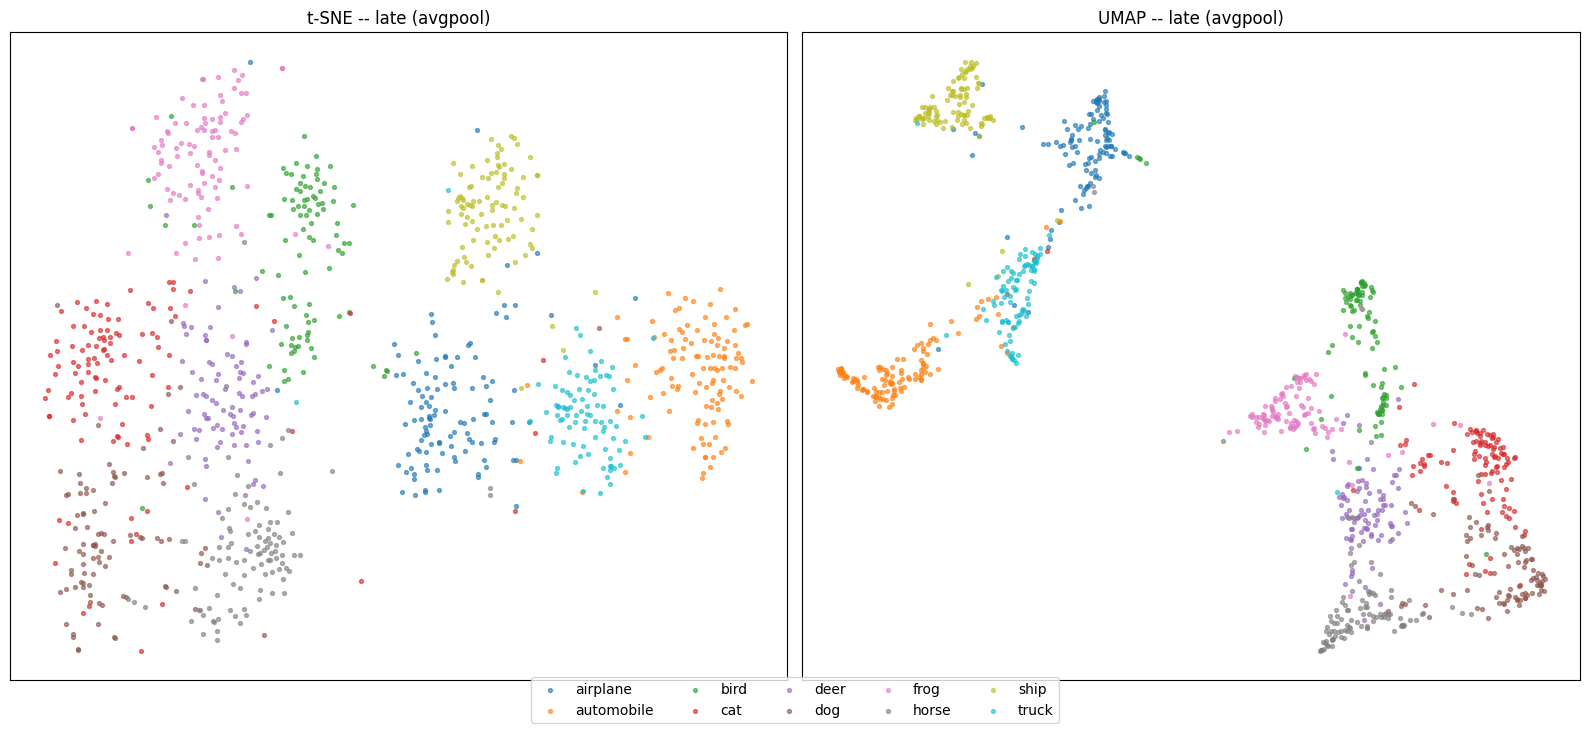

In [23]:
# (a) t-SNE vs. UMAP, late-stage features only -- this is the stage that
# actually drives the classifier's decisions, so it's the one where "does
# one method show class structure more clearly" is a meaningful question.
late_np = multistage_feats["late"].numpy()

tsne_late = TSNE(n_components=2, perplexity=30, init="pca", random_state=42).fit_transform(late_np)
umap_late = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(late_np)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_class_scatter(axes[0], tsne_late, multistage_feats["labels"], classes_cifar, "t-SNE -- late (avgpool)")
plot_class_scatter(axes[1], umap_late, multistage_feats["labels"], classes_cifar, "UMAP -- late (avgpool)")
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

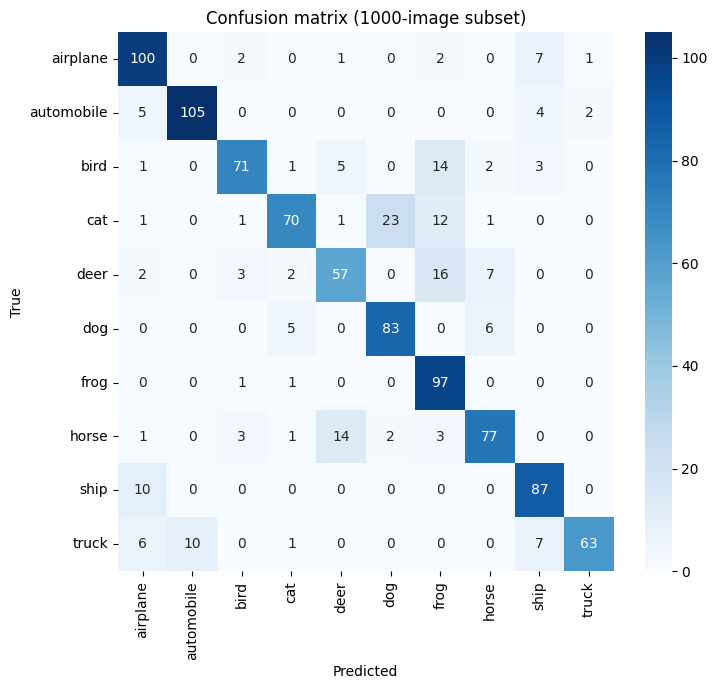

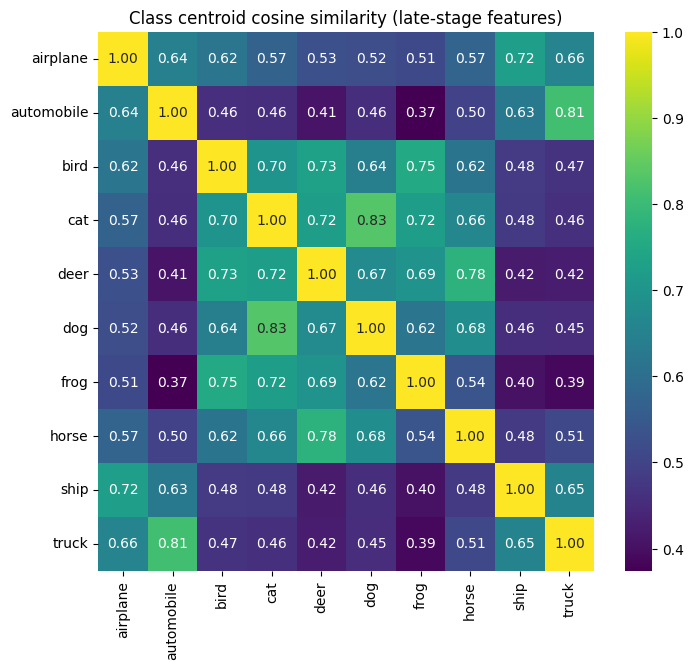

Top confused pairs (true -> predicted):
  cat          -> dog         : 23 misclassified (of 1000-sample subset), centroid cosine similarity=0.832
  deer         -> frog        : 16 misclassified (of 1000-sample subset), centroid cosine similarity=0.695
  horse        -> deer        : 14 misclassified (of 1000-sample subset), centroid cosine similarity=0.777
  bird         -> frog        : 14 misclassified (of 1000-sample subset), centroid cosine similarity=0.752
  cat          -> frog        : 12 misclassified (of 1000-sample subset), centroid cosine similarity=0.719


In [25]:
# (b) Which classes does the model confuse, and does that line up with
# feature-space closeness? Confusion matrix + predictions come from the same
# 1000-image pass as the embeddings above, so everything here is consistent.

from sklearn.metrics.pairwise import cosine_similarity

y_true_ms = multistage_feats["labels"].numpy()
y_pred_ms = multistage_feats["preds"].numpy()

cm = confusion_matrix(y_true_ms, y_pred_ms)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes_cifar, yticklabels=classes_cifar)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix (1000-image subset)")
plt.show()

# Class centroids in late-stage feature space -- classes confused more often
# should have measurably closer (more similar) centroids.
centroids = np.stack([late_np[y_true_ms == c].mean(axis=0) for c in range(len(classes_cifar))])
centroid_sim = cosine_similarity(centroids)

plt.figure(figsize=(8, 7))
sns.heatmap(centroid_sim, annot=True, fmt=".2f", cmap="viridis", xticklabels=classes_cifar, yticklabels=classes_cifar)
plt.title("Class centroid cosine similarity (late-stage features)")
plt.show()

# Top confused pairs, cross-referenced against centroid similarity.
cm_off_diag = cm.copy()
np.fill_diagonal(cm_off_diag, 0)
confused_pairs = [
    (cm_off_diag[i, j], classes_cifar[i], classes_cifar[j])
    for i in range(len(classes_cifar))
    for j in range(len(classes_cifar))
    if i != j
]
confused_pairs.sort(reverse=True)

print("Top confused pairs (true -> predicted):")
for count, true_c, pred_c in confused_pairs[:5]:
    sim = centroid_sim[classes_cifar.index(true_c), classes_cifar.index(pred_c)]
    print(f"  {true_c:12s} -> {pred_c:12s}: {count} misclassified (of {len(y_true_ms)}-sample subset), centroid cosine similarity={sim:.3f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /content/drive/MyDrive/ATML/assignment_00/task1_resnet152/torch_cache/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 37.4MB/s]
extracting features: 100%|██████████| 32/32 [00:04<00:00,  7.51it/s]


Epoch: 1/5 | Train Loss: 1.5609, Train Acc: 53.86% | Val Loss 1.00% Val Acc:76.15%
Epoch: 2/5 | Train Loss: 0.8161, Train Acc: 78.99% | Val Loss 0.71% Val Acc:80.45%
Epoch: 3/5 | Train Loss: 0.6305, Train Acc: 82.69% | Val Loss 0.61% Val Acc:82.00%
Epoch: 4/5 | Train Loss: 0.5489, Train Acc: 84.14% | Val Loss 0.57% Val Acc:82.85%
Epoch: 5/5 | Train Loss: 0.5021, Train Acc: 84.90% | Val Loss 0.52% Val Acc:83.65%
------------------------------
FINAL TEST RESULT
Test Loss: 0.5030
Test Accuracy: 84.30%
------------------------------

Classification Report:
               precision    recall  f1-score   support

    airplane       0.89      0.89      0.89       221
  automobile       0.94      0.91      0.92       222
        bird       0.79      0.75      0.77       195
         cat       0.78      0.69      0.74       206
        deer       0.81      0.75      0.78       192
         dog       0.80      0.78      0.79       190
        frog       0.85      0.91      0.88       195
       

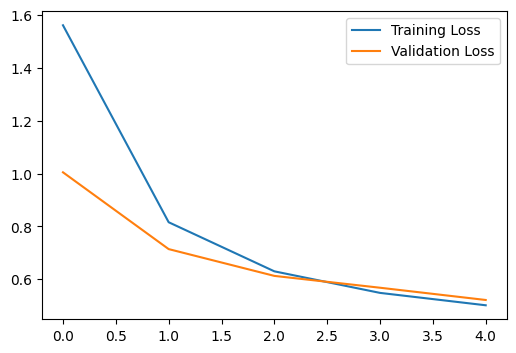

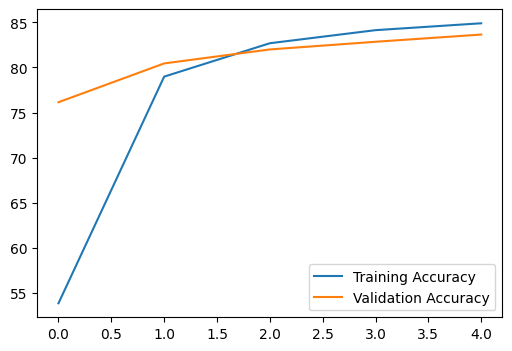

In [26]:
# (c) ResNet-152 vs. a shallower ResNet-18 -- same frozen-backbone pipeline
# from Section 1, just swapping the model. extract_features/train_head_on_features
# already read the feature dimension dynamically, so this needs no other changes.
resnet18_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(DEVICE)
resnet18_model.eval()
for p in resnet18_model.parameters():
    p.requires_grad = False

X_train_r18, y_train_r18 = extract_features(resnet18_model, train_loader, cache_path=f'{RUN_DIR}/features/resnet18_train.pt')
X_val_r18, y_val_r18 = extract_features(resnet18_model, val_loader, cache_path=f'{RUN_DIR}/features/resnet18_val.pt')

resnet18_head, resnet18_results = train_head_on_features(X_train_r18, y_train_r18, X_val_r18, y_val_r18, NUM_CLASSES)

resnet18_model.fc = resnet18_head
resnet18_test_loss, resnet18_test_acc, _, _ = test_and_report(resnet18_model, test_loader, nn.CrossEntropyLoss(), classes_cifar)
plot_loss_acc(resnet18_results)

resnet152_params = sum(p.numel() for p in resnet_model.parameters())
resnet18_params = sum(p.numel() for p in resnet18_model.parameters())
print(f"ResNet-152: {baseline_test_acc_s4:.2f}% test acc | {resnet152_params:,} total params")
print(f"ResNet-18:  {resnet18_test_acc:.2f}% test acc | {resnet18_params:,} total params")

save_checkpoint(resnet18_head.state_dict(), 'resnet18_head')

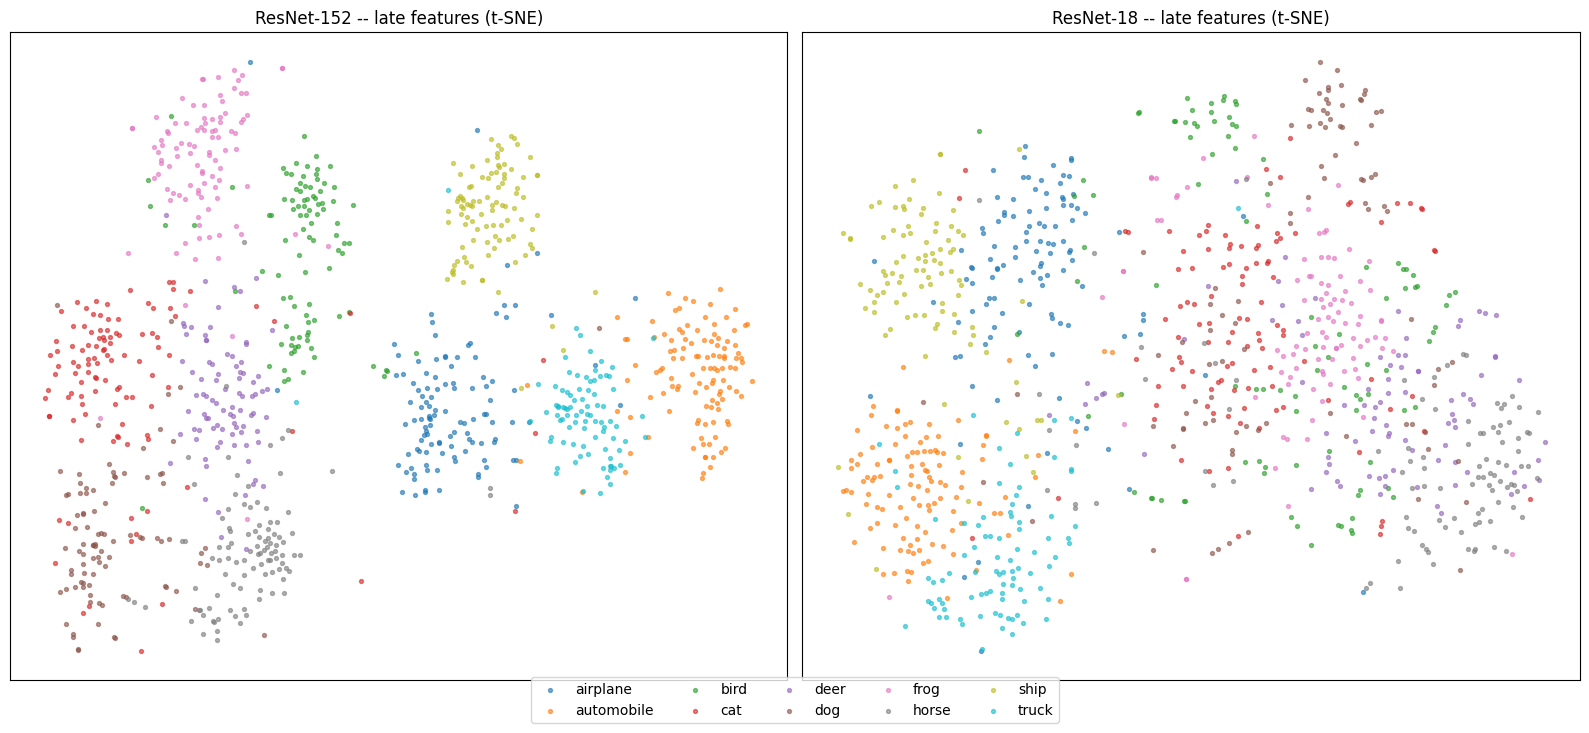

In [27]:
# Bonus: same multi-stage collector, same late-stage t-SNE, just pointed at
# ResNet-18 instead of ResNet-152 -- a direct visual comparison of feature
# quality between the two backbones on the same images.
r18_feats = collect_multistage_features(resnet18_model, test_loader, max_samples=1000)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
coords_152 = TSNE(n_components=2, perplexity=30, init="pca", random_state=42).fit_transform(multistage_feats["late"].numpy())
coords_18 = TSNE(n_components=2, perplexity=30, init="pca", random_state=42).fit_transform(r18_feats["late"].numpy())
plot_class_scatter(axes[0], coords_152, multistage_feats["labels"], classes_cifar, "ResNet-152 -- late features (t-SNE)")
plot_class_scatter(axes[1], coords_18, r18_feats["labels"], classes_cifar, "ResNet-18 -- late features (t-SNE)")
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()